# Exploratory Data Analysis — Maternal Postnatal Care Risk Stratification

This notebook performs a complete exploratory data analysis (EDA) of the cleaned Kenya DHS 2022 maternal postnatal-care modelling data.

**Source:** `maternal_pnc_visualization_data.csv` (10,505 women, 18 columns)

**Outcome:** `missed_timely_pnc`

- `0` = received a postnatal check within two days
- `1` = missed timely postnatal care

The analysis is deliberately written in simple, reusable Python. It describes the modelling sample, examines every predictor, tests exploratory associations, and records the implications for modelling.

The file contains DHS sample weights and sampling-cluster identifiers. This notebook reports both unweighted sample descriptions and survey-weighted descriptive estimates. Weighting improves representativeness, but full design-based standard errors would additionally require the survey strata variable, which is not present. The results show association, not causation.

## 1. EDA objective

The EDA answers four practical questions:

1. Is the cleaned dataset internally consistent and ready for analysis?
2. How are the target and the 13 predictors distributed?
3. Which characteristics appear associated with missing timely PNC?
4. What preprocessing, validation, and evaluation decisions should carry into modelling?

The notebook does not alter the source CSV and does not impute missing values. Imputation must be learned later from training data only.

## 2. Imports, display settings, and reusable functions

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import mutual_info_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TARGET = "missed_timely_pnc"
TARGET_LABELS = {0: "Received timely PNC", 1: "Missed timely PNC"}

numeric_features = [
    "maternal_age",
    "children_ever_born",
    "first_anc_month",
    "anc_visits",
]

categorical_features = [
    "pregnancy_outcome",
    "county_name",
    "residence",
    "education_level",
    "wealth_quintile",
    "marital_status",
    "currently_working",
    "pregnancy_intention",
    "delivery_place",
    "caesarean_delivery",
]

# Administrative and survey-design fields used for auditing, weighting, and grouping—not predictors.
analysis_fields = ["cluster_id", "sample_weight", "county_code"]

ordered_categories = {
    "education_level": ["No education", "Primary", "Secondary", "Higher"],
    "wealth_quintile": ["Poorest", "Poorer", "Middle", "Richer", "Richest"],
    "residence": ["Urban", "Rural"],
    "currently_working": ["No", "Yes"],
    "pregnancy_intention": ["Wanted then", "Wanted later", "Wanted no more"],
    "caesarean_delivery": ["No", "Yes"],
}

def add_rate_interval(table, successes="missed", total="women"):
    # Add missed-PNC rate and a simple 95% Wilson confidence interval.
    z = 1.96
    n = table[total].astype(float)
    p = table[successes] / n
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p * (1 - p) / n) + z**2 / (4 * n**2)) / denominator
    table = table.copy()
    table["missed_rate"] = p
    table["ci_low"] = (centre - margin).clip(0)
    table["ci_high"] = (centre + margin).clip(1)
    return table

def target_rate_table(data, feature, order=None):
    # Return count, missed count, rate, and 95% interval for each category.
    table = (
        data.groupby(feature, observed=False)[TARGET]
        .agg(women="size", missed="sum")
        .reset_index()
    )
    table = add_rate_interval(table)
    weighted = (
        data.assign(weighted_target=data[TARGET] * data["sample_weight"])
        .groupby(feature, observed=False)
        .agg(weight_sum=("sample_weight", "sum"), weighted_missed=("weighted_target", "sum"))
        .reset_index()
    )
    weighted["weighted_missed_rate"] = weighted["weighted_missed"] / weighted["weight_sum"]
    table = table.merge(weighted[[feature, "weight_sum", "weighted_missed_rate"]], on=feature, how="left")
    if order is not None:
        table[feature] = pd.Categorical(table[feature], categories=order, ordered=True)
        table = table.sort_values(feature)
    return table.reset_index(drop=True)

def plot_rate_table(table, feature, title, sort=True):
    # Plot category missed-PNC rates with 95% intervals.
    shown = table.copy()
    if sort:
        shown = shown.sort_values("missed_rate", ascending=True)
    low = shown["missed_rate"] - shown["ci_low"]
    high = shown["ci_high"] - shown["missed_rate"]
    fig_height = max(4, 0.38 * len(shown))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.errorbar(
        shown["missed_rate"] * 100,
        shown[feature].astype(str),
        xerr=np.vstack([low, high]) * 100,
        fmt="o",
        capsize=3,
        color="#B23A48",
    )
    ax.set(title=title + " (unweighted sample rate with 95% interval)", xlabel="Women who missed timely PNC (%)", ylabel="")
    plt.tight_layout()
    plt.show()

def cramers_v(table):
    # Bias-corrected Cramer's V: strength of association between categories.
    observed = np.asarray(table)
    if observed.size == 0 or observed.sum() == 0:
        return np.nan
    chi2 = stats.chi2_contingency(observed, correction=False)[0]
    n = observed.sum()
    phi2 = chi2 / n
    rows, columns = observed.shape
    phi2_corrected = max(0, phi2 - ((columns - 1) * (rows - 1)) / (n - 1))
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)
    return np.sqrt(phi2_corrected / denominator) if denominator > 0 else 0.0

## 3. Load the cleaned data

The next cell searches the current folder and its parents for `maternal_pnc_visualization_data.csv`. This makes the notebook portable when opened from the Capstone folder or a nearby notebook folder.

In [2]:
cwd = Path.cwd().resolve()
search_folders = [cwd, *cwd.parents]
CSV_PATH = next(
    (folder / "maternal_pnc_visualization_data.csv" for folder in search_folders
     if (folder / "maternal_pnc_visualization_data.csv").exists()),
    None,
)

if CSV_PATH is None:
    raise FileNotFoundError("Could not find maternal_pnc_visualization_data.csv")

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH.name}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
display(df.head())

Loaded: maternal_pnc_visualization_data.csv
Rows: 10,505 | Columns: 18


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
0,480,0.828,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3.000,6.000,Private facility,Yes,0
1,1495,0.832,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6.000,3.000,Private facility,Yes,0
2,1033,0.472,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3.000,6.000,Public facility,No,0
3,1198,1.090,34,Live birth,33,Kajiado,Rural,Primary,Poorest,5,Married,No,Wanted then,3.000,6.000,Home,No,0
4,722,1.529,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6.000,4.000,Public facility,No,1


## 4. Data-quality and structure checks

These checks verify the expected schema, data types, duplicates, target values, ranges, and category labels. Exact duplicate predictor rows are reported but not automatically removed: different women can legitimately share the same characteristics now that identifiers are absent.

In [3]:
expected_columns = analysis_fields + numeric_features + categorical_features + [TARGET]

quality_checks = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Expected columns present",
        "Unexpected columns",
        "Exact duplicate rows",
        "Missing target values",
        "Target values",
    ],
    "result": [
        f"{len(df):,}",
        df.shape[1],
        set(expected_columns).issubset(df.columns),
        sorted(set(df.columns) - set(expected_columns)),
        int(df.duplicated().sum()),
        int(df[TARGET].isna().sum()),
        sorted(df[TARGET].dropna().unique().tolist()),
    ],
})
display(quality_checks)

print("Data types:")
display(df.dtypes.rename("dtype").to_frame())

assert df.shape == (10505, 18), "The file does not have the expected 10,505 x 18 shape."
assert set(df.columns) == set(expected_columns), "The CSV schema differs from the approved schema."
assert df[TARGET].notna().all(), "The target has missing values."
assert df[TARGET].isin([0, 1]).all(), "The target must contain only 0 and 1."
assert df["maternal_age"].between(15, 49).all(), "Maternal age is outside 15–49."
assert df["children_ever_born"].ge(0).all(), "Children ever born contains a negative value."
assert df["first_anc_month"].dropna().between(1, 10).all(), "ANC month is outside 1–10."
assert df["anc_visits"].dropna().between(0, 20).all(), "ANC visits is outside 0–20."
assert df["sample_weight"].gt(0).all(), "Sample weights must be positive."
assert df["cluster_id"].nunique() == 1680, "Unexpected number of sampling clusters."
assert df["county_code"].between(1, 47).all(), "County code is outside 1–47."
assert not df.groupby("county_code")["county_name"].nunique().gt(1).any(), "A county code maps to multiple names."
assert not df.groupby("county_name")["county_code"].nunique().gt(1).any(), "A county name maps to multiple codes."
print("All core structure and range checks passed.")

,check,result
0,Rows,"10,505"
1,Columns,18
2,Expected columns present,True
3,Unexpected columns,[]
4,Exact duplicate rows,3
5,Missing target values,0
6,Target values,"[0, 1]"


Data types:


,dtype
cluster_id,int64
sample_weight,float64
county_code,int64
pregnancy_outcome,str
maternal_age,int64
county_name,str
residence,str
education_level,str
wealth_quintile,str
children_ever_born,int64


All core structure and range checks passed.


In [4]:
# Examine exact duplicate patterns without assuming they are duplicate women.
duplicate_patterns = (
    df[df.duplicated(keep=False)]
    .value_counts(dropna=False)
    .rename("identical_rows")
    .reset_index()
    .sort_values("identical_rows", ascending=False)
)
print(f"Distinct repeated predictor/target patterns: {len(duplicate_patterns):,}")
display(duplicate_patterns.head(10))

Distinct repeated predictor/target patterns: 3


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc,identical_rows
0,317,0.224,10,Live birth,19,Marsabit,Urban,Primary,Richer,1,Married,No,Wanted then,4.000,6.000,Public facility,No,1,2
1,298,0.285,9,Live birth,44,Mandera,Rural,No education,Poorest,11,Married,No,Wanted then,NaN,0.000,Home,No,1,2
2,300,0.376,9,Live birth,29,Mandera,Urban,No education,Poorest,7,Married,No,Wanted then,1.000,7.000,Public facility,No,0,2


## 5. Variable classification and full descriptive summary

The four numeric predictors are measured as numbers or counts. The remaining nine predictors are categories. The summary below provides a compact audit of every field before plotting it.

In [5]:
print("Numeric predictors:", numeric_features)
print("Categorical predictors:", categorical_features)
print("Analysis-only fields:", analysis_fields)

numeric_summary = df[numeric_features].describe().T
numeric_summary["missing"] = df[numeric_features].isna().sum()
numeric_summary["missing_percent"] = 100 * df[numeric_features].isna().mean()
numeric_summary["median"] = df[numeric_features].median()
numeric_summary["skewness"] = df[numeric_features].skew()
numeric_summary["unique"] = df[numeric_features].nunique()
display(numeric_summary)

categorical_summary = pd.DataFrame({
    "unique_categories": df[categorical_features].nunique(),
    "missing": df[categorical_features].isna().sum(),
    "missing_percent": 100 * df[categorical_features].isna().mean(),
    "most_common": [df[column].mode().iat[0] for column in categorical_features],
    "most_common_count": [df[column].value_counts().iat[0] for column in categorical_features],
})
display(categorical_summary)

survey_summary = pd.DataFrame({
    "measure": ["Unique clusters", "Unique county codes", "Weight minimum", "Weight median", "Weight maximum", "Weight sum"],
    "value": [df["cluster_id"].nunique(), df["county_code"].nunique(), df["sample_weight"].min(),
              df["sample_weight"].median(), df["sample_weight"].max(), df["sample_weight"].sum()],
})
display(survey_summary)

county_crosswalk = df[["county_code", "county_name"]].drop_duplicates().sort_values("county_code")
display(county_crosswalk)

Numeric predictors: ['maternal_age', 'children_ever_born', 'first_anc_month', 'anc_visits']
Categorical predictors: ['pregnancy_outcome', 'county_name', 'residence', 'education_level', 'wealth_quintile', 'marital_status', 'currently_working', 'pregnancy_intention', 'delivery_place', 'caesarean_delivery']
Analysis-only fields: ['cluster_id', 'sample_weight', 'county_code']


,count,mean,std,min,25%,50%,75%,max,missing,missing_percent,median,skewness,unique
maternal_age,"10,505.000",28.259,6.613,15.000,23.000,27.000,33.000,49.000,0,0.000,27.000,0.414,35
children_ever_born,"10,505.000",3.158,2.222,0.000,1.000,3.000,4.000,14.000,0,0.000,3.000,1.261,15
first_anc_month,"10,108.000",4.437,1.628,1.000,3.000,4.000,6.000,10.000,397,3.779,4.000,-0.004,10
anc_visits,"10,495.000",4.059,1.821,0.000,3.000,4.000,5.000,20.000,10,0.095,4.000,0.417,19


,unique_categories,missing,missing_percent,most_common,most_common_count
pregnancy_outcome,2,0,0.000,Live birth,10363
county_name,47,0,0.000,West Pokot,423
residence,2,0,0.000,Rural,6870
education_level,4,0,0.000,Primary,3548
wealth_quintile,5,0,0.000,Poorest,3289
marital_status,6,0,0.000,Married,7690
currently_working,2,0,0.000,No,6045
pregnancy_intention,3,0,0.000,Wanted then,6823
delivery_place,5,0,0.000,Public facility,6705
caesarean_delivery,2,0,0.000,No,9082


,measure,value
0,Unique clusters,"1,680.000"
1,Unique county codes,47.000
2,Weight minimum,0.041
3,Weight median,0.725
4,Weight maximum,9.823
5,Weight sum,"9,539.540"


,county_code,county_name
29,1,Mombasa
55,2,Kwale
121,3,Kilifi
12,4,Tana River
47,5,Lamu
20,6,Taita Taveta
28,7,Garissa
13,8,Wajir
10,9,Mandera
9,10,Marsabit


## 6. Target analysis

The target distribution establishes the baseline difficulty of the classification problem. A model predicting the majority class for everyone would appear accurate but would identify no women who missed timely care, so later evaluation must emphasize PR-AUC, recall, precision, and F1-score.

,missed_timely_pnc,label,women,percent
0,0,Received timely PNC,7814,74.384
1,1,Missed timely PNC,2691,25.616


Survey-weighted missed-PNC estimate: 21.5%
Majority-class accuracy baseline: 74.4%


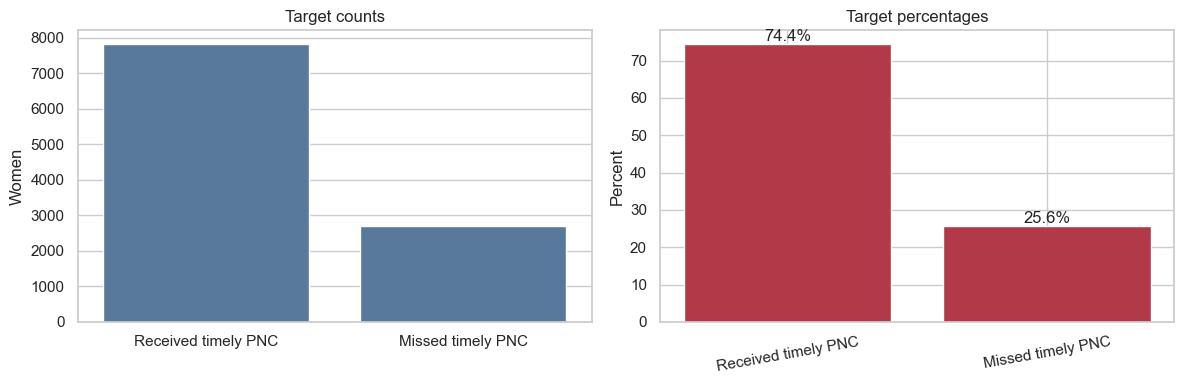

,estimate,missed_rate_percent
0,Unweighted modelling sample,25.616
1,Survey-weighted descriptive estimate,21.513


In [6]:
target_summary = (
    df[TARGET].value_counts().sort_index()
    .rename_axis(TARGET).reset_index(name="women")
)
target_summary["label"] = target_summary[TARGET].map(TARGET_LABELS)
target_summary["percent"] = 100 * target_summary["women"] / len(df)
display(target_summary[[TARGET, "label", "women", "percent"]])

weighted_target_rate = np.average(df[TARGET], weights=df["sample_weight"])
print(f"Survey-weighted missed-PNC estimate: {weighted_target_rate:.1%}")

majority_baseline = target_summary["women"].max() / len(df)
print(f"Majority-class accuracy baseline: {majority_baseline:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df.assign(target_label=df[TARGET].map(TARGET_LABELS)),
              x="target_label", color="#4C78A8", ax=axes[0])
axes[0].set(title="Target counts", xlabel="", ylabel="Women")

axes[1].bar(target_summary["label"], target_summary["percent"], color="#B23A48")
axes[1].set(title="Target percentages", xlabel="", ylabel="Percent")
axes[1].tick_params(axis="x", rotation=10)
for position, value in enumerate(target_summary["percent"]):
    axes[1].text(position, value + 1, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

target_comparison = pd.DataFrame({
    "estimate": ["Unweighted modelling sample", "Survey-weighted descriptive estimate"],
    "missed_rate_percent": [100 * df[TARGET].mean(), 100 * weighted_target_rate],
})
display(target_comparison)

## 7. Missing-data analysis

Missingness is described overall and compared with the outcome. A separate missingness flag is created only in memory for exploration; the source CSV is unchanged. A difference in outcome rate may mean that missingness itself is informative, but it does not prove why a value is missing.

,missing_rows,missing_percent
first_anc_month,397,3.779
anc_visits,10,0.095
cluster_id,0,0.000
sample_weight,0,0.000
caesarean_delivery,0,0.000
delivery_place,0,0.000
pregnancy_intention,0,0.000
currently_working,0,0.000
marital_status,0,0.000
children_ever_born,0,0.000


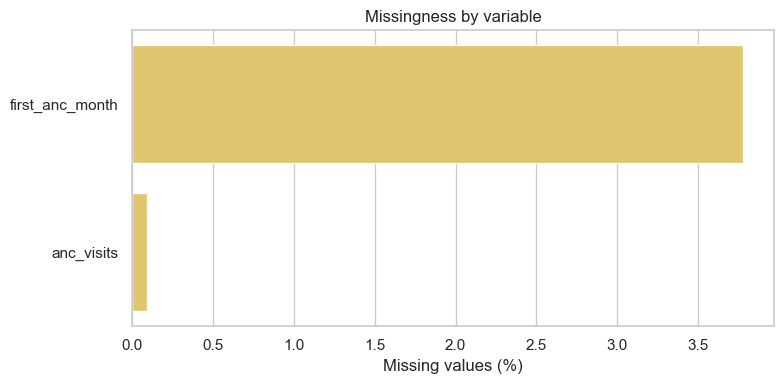

In [7]:
missing_summary = pd.DataFrame({
    "missing_rows": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean(),
}).sort_values("missing_rows", ascending=False)
display(missing_summary)

missing_only = missing_summary.query("missing_rows > 0")
if not missing_only.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=missing_only.reset_index(), x="missing_percent", y="index", color="#F2CF5B")
    plt.xlabel("Missing values (%)")
    plt.ylabel("")
    plt.title("Missingness by variable")
    plt.tight_layout()
    plt.show()

In [8]:
missing_target_results = []
for feature in numeric_features:
    missing_flag = df[feature].isna()
    if missing_flag.any():
        table = pd.crosstab(missing_flag, df[TARGET])
        chi2, p_value, _, _ = stats.chi2_contingency(table)
        for is_missing in [False, True]:
            group = df.loc[missing_flag == is_missing, TARGET]
            missing_target_results.append({
                "feature": feature,
                "status": "Missing" if is_missing else "Observed",
                "women": len(group),
                "missed_rate_percent": 100 * group.mean(),
                "chi_square_p_value": p_value,
            })

missing_target_results = pd.DataFrame(missing_target_results)
display(missing_target_results)

both_anc_missing = df["first_anc_month"].isna() & df["anc_visits"].isna()
print(f"Rows missing both ANC fields: {both_anc_missing.sum():,}")
display(pd.crosstab(
    df["first_anc_month"].isna().map({False: "Month observed", True: "Month missing"}),
    df["anc_visits"].isna().map({False: "Visits observed", True: "Visits missing"}),
))

,feature,status,women,missed_rate_percent,chi_square_p_value
0,first_anc_month,Observed,10108,23.803,0.000
1,first_anc_month,Missing,397,71.788,0.000
2,anc_visits,Observed,10495,25.603,0.496
3,anc_visits,Missing,10,40.000,0.496


Rows missing both ANC fields: 1


anc_visits,Visits missing,Visits observed
first_anc_month,,
Month missing,1,396
Month observed,9,10099


## 8. Univariate analysis of numeric predictors

Histograms show shape and common values; boxplots show median, spread, and potential outliers. A point beyond a boxplot whisker is not automatically an error—it may be a valid high-parity or high-visit observation.

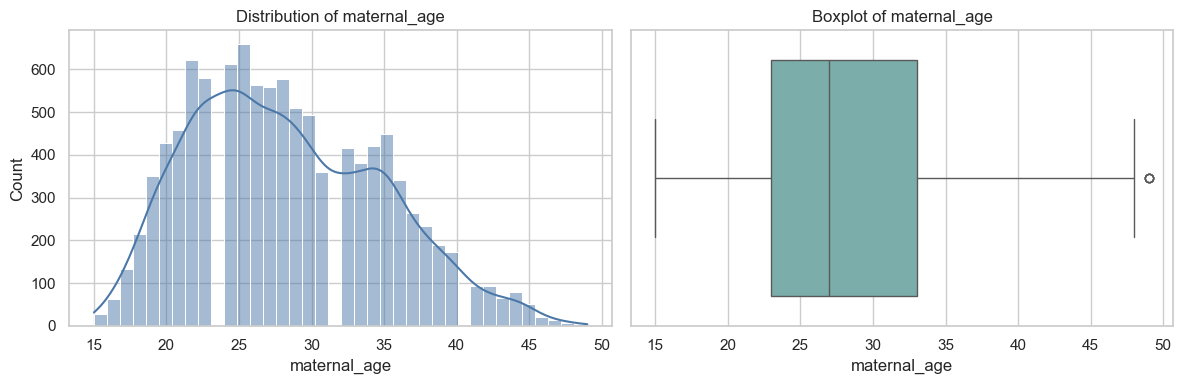

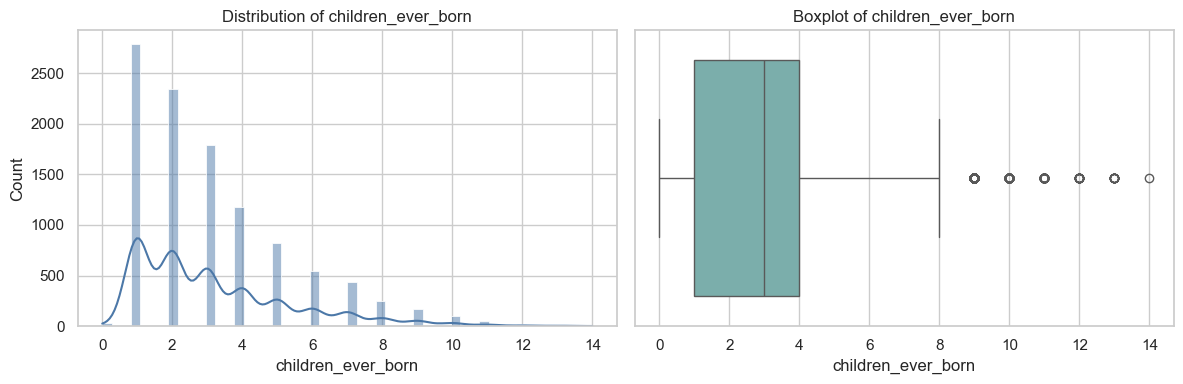

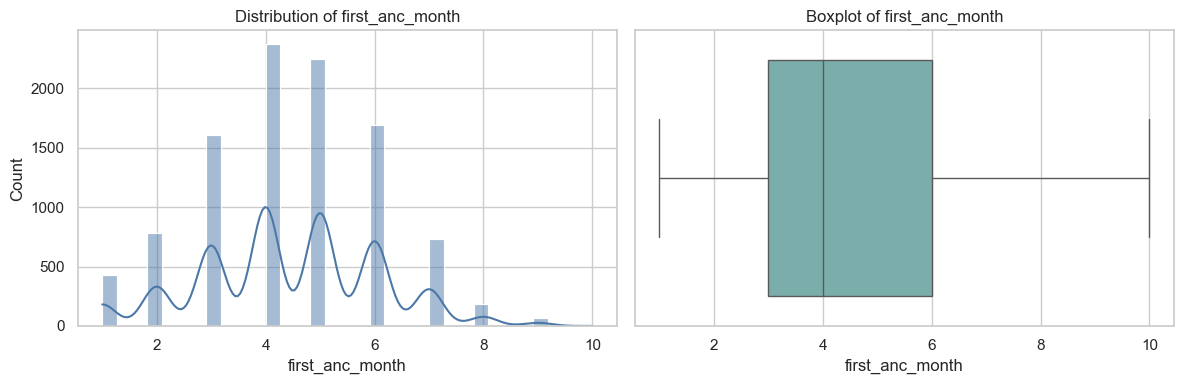

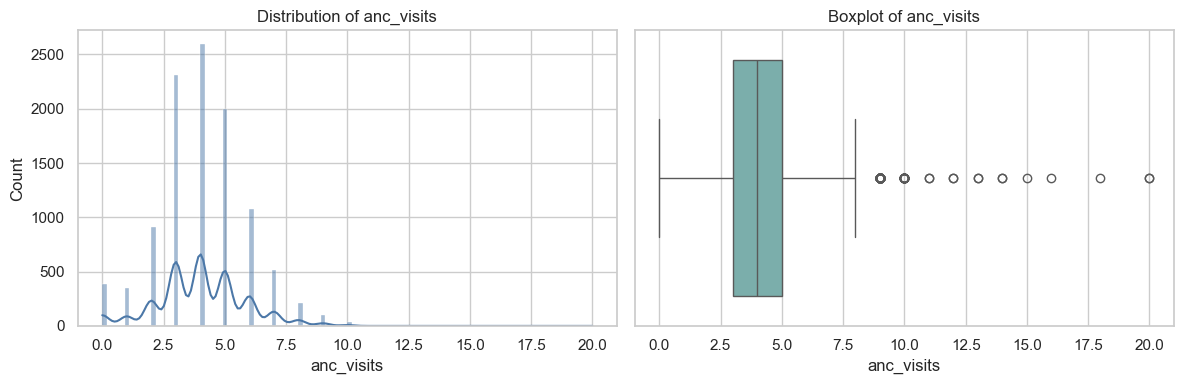

In [9]:
for feature in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=feature, bins="auto", kde=True, color="#4C78A8", ax=axes[0])
    axes[0].set_title(f"Distribution of {feature}")
    sns.boxplot(data=df, x=feature, color="#72B7B2", ax=axes[1])
    axes[1].set_title(f"Boxplot of {feature}")
    plt.tight_layout()
    plt.show()

In [10]:
# IQR flags are descriptive only; they are not deleted.
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = ((values < lower) | (values > upper)).sum()
    outlier_rows.append({
        "feature": feature, "q1": q1, "q3": q3,
        "lower_fence": lower, "upper_fence": upper,
        "flagged_rows": flagged, "flagged_percent": 100 * flagged / len(values),
        "observed_min": values.min(), "observed_max": values.max(),
    })
display(pd.DataFrame(outlier_rows))

,feature,q1,q3,lower_fence,upper_fence,flagged_rows,flagged_percent,observed_min,observed_max
0,maternal_age,23.000,33.000,8.000,48.000,4,0.038,15.000,49.000
1,children_ever_born,1.000,4.000,-3.500,8.500,332,3.160,0.000,14.000
2,first_anc_month,3.000,6.000,-1.500,10.500,0,0.000,1.000,10.000
3,anc_visits,3.000,5.000,0.000,8.000,143,1.363,0.000,20.000


## 9. Univariate analysis of categorical predictors

Every categorical predictor is summarized using counts and percentages. Horizontal plots keep long category names readable. County is plotted separately because it has 47 categories.


pregnancy_outcome


,pregnancy_outcome,women,percent
0,Live birth,10363,98.648
1,Stillbirth,142,1.352


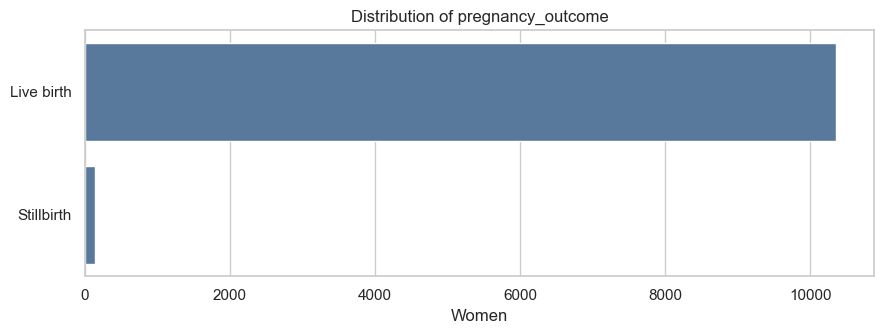


residence


,residence,women,percent
0,Rural,6870,65.397
1,Urban,3635,34.603


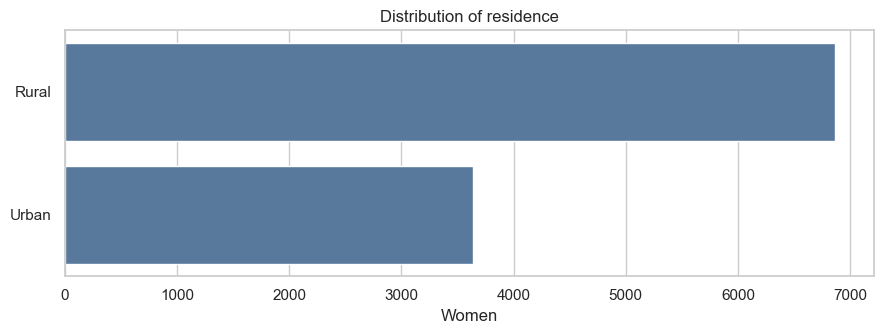


education_level


,education_level,women,percent
0,Primary,3548,33.774
1,Secondary,3302,31.433
2,No education,2124,20.219
3,Higher,1531,14.574


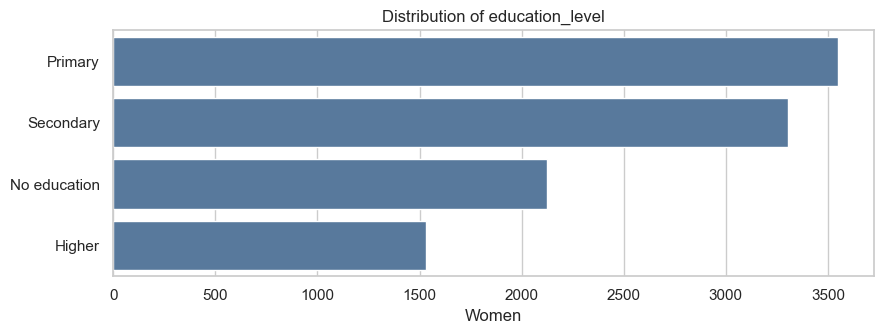


wealth_quintile


,wealth_quintile,women,percent
0,Poorest,3289,31.309
1,Richer,2064,19.648
2,Middle,1841,17.525
3,Poorer,1775,16.897
4,Richest,1536,14.622


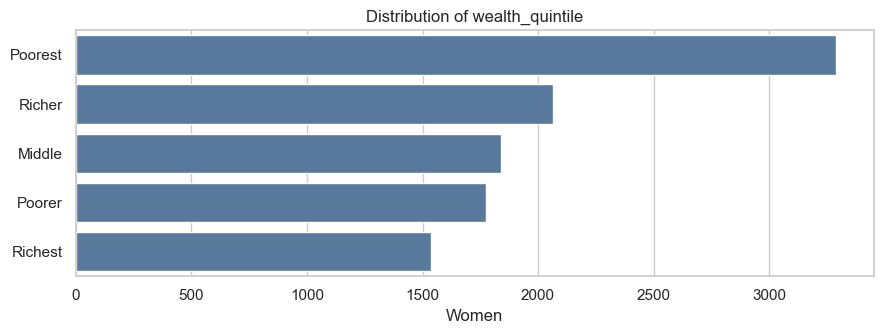


marital_status


,marital_status,women,percent
0,Married,7690,73.203
1,Never married,1100,10.471
2,Living with partner,814,7.749
3,Separated,602,5.731
4,Widowed,167,1.590
5,Divorced,132,1.257


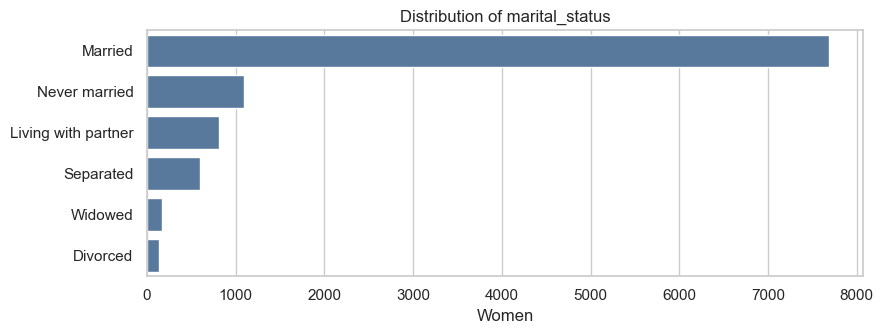


currently_working


,currently_working,women,percent
0,No,6045,57.544
1,Yes,4460,42.456


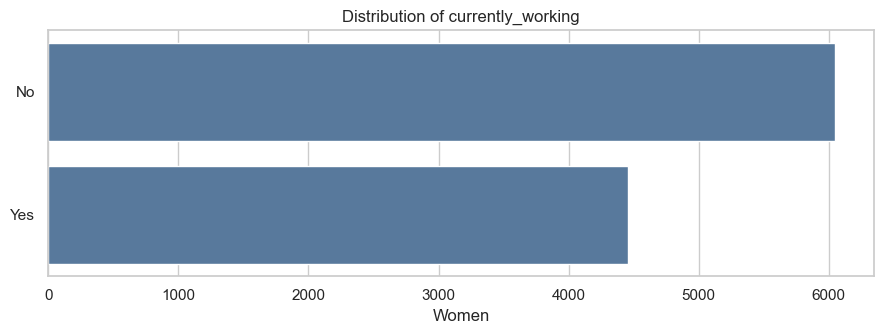


pregnancy_intention


,pregnancy_intention,women,percent
0,Wanted then,6823,64.950
1,Wanted later,2858,27.206
2,Wanted no more,824,7.844


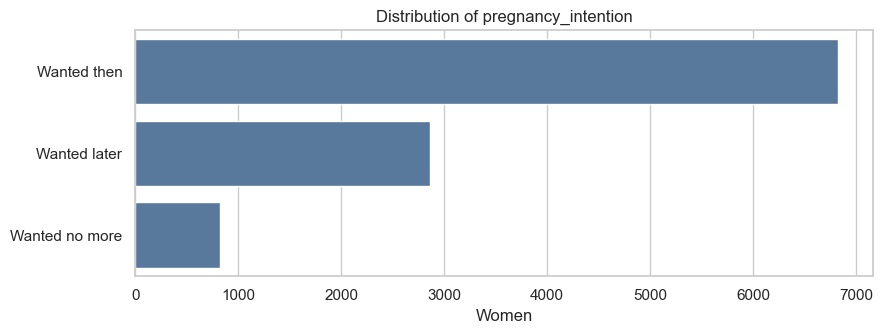


delivery_place


,delivery_place,women,percent
0,Public facility,6705,63.827
1,Home,1930,18.372
2,Private facility,1284,12.223
3,Faith-based/NGO facility,528,5.026
4,Other,58,0.552


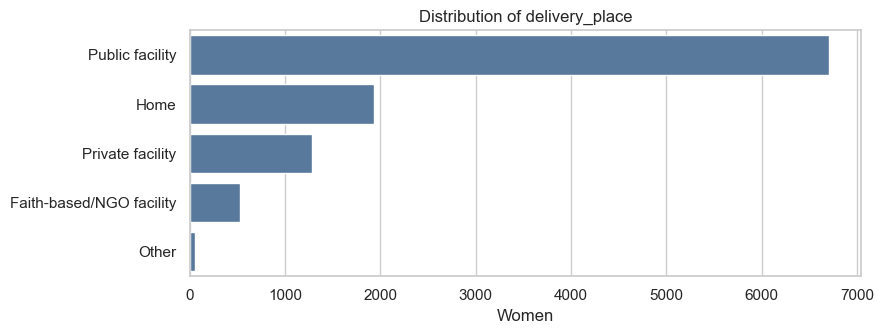


caesarean_delivery


,caesarean_delivery,women,percent
0,No,9082,86.454
1,Yes,1423,13.546


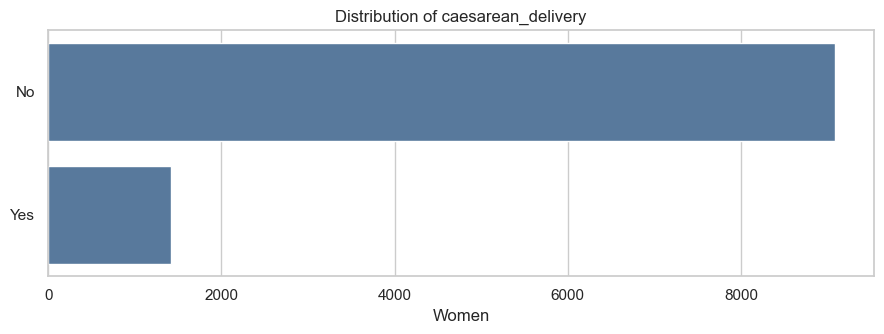

In [11]:
for feature in [column for column in categorical_features if column != "county_name"]:
    counts = df[feature].value_counts(dropna=False).rename_axis(feature).reset_index(name="women")
    counts["percent"] = 100 * counts["women"] / len(df)
    print(f"\n{feature}")
    display(counts)

    plt.figure(figsize=(9, max(3.5, 0.5 * len(counts))))
    sns.barplot(data=counts, x="women", y=feature, color="#4C78A8")
    plt.title(f"Distribution of {feature}")
    plt.xlabel("Women")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

,county_name,women,percent
46,West Pokot,423,4.027
45,Mandera,399,3.798
44,Samburu,313,2.980
43,Turkana,309,2.941
42,Tana River,307,2.922
41,Narok,307,2.922
40,Wajir,306,2.913
39,Marsabit,278,2.646
38,Migori,278,2.646
37,Garissa,267,2.542


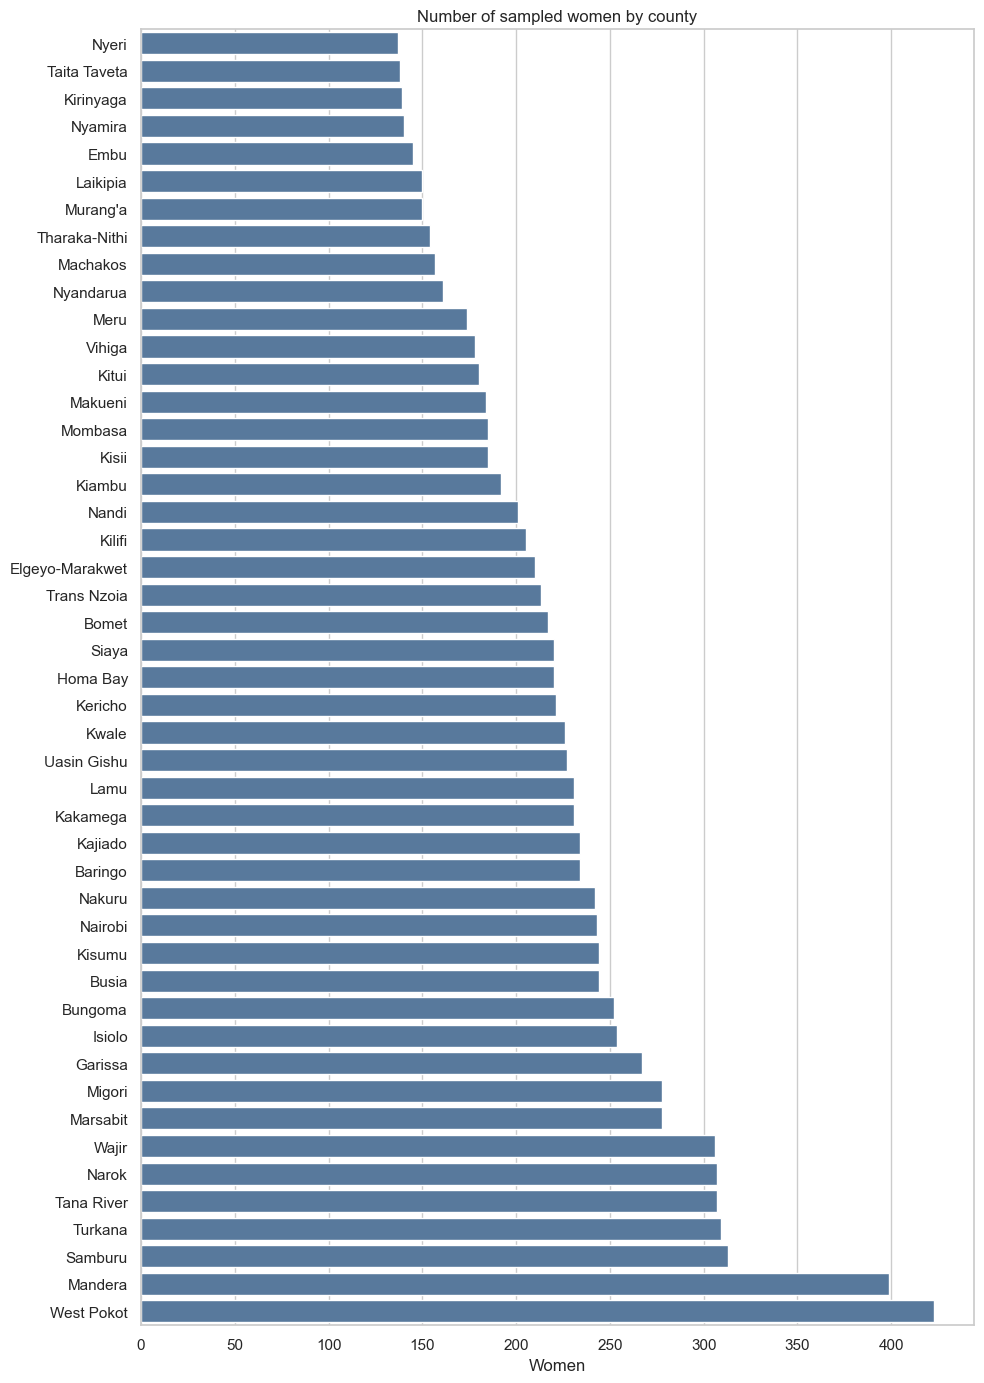

In [12]:
county_counts = df["county_name"].value_counts().sort_values().rename_axis("county_name").reset_index(name="women")
county_counts["percent"] = 100 * county_counts["women"] / len(df)
display(county_counts.sort_values("women", ascending=False))

plt.figure(figsize=(10, 14))
sns.barplot(data=county_counts, x="women", y="county_name", color="#4C78A8")
plt.title("Number of sampled women by county")
plt.xlabel("Women")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 10. Numeric predictors compared with the target

The grouped summaries and plots compare women who received timely care with women who missed it. The binned versions are used only to communicate patterns; original numeric values remain the preferred model inputs.

maternal_age                     children_ever_born        \
                           count   mean median   std              count  mean   
missed_timely_pnc                                                               
Received timely PNC         7814 28.070 27.000 6.510               7814 2.919   
Missed timely PNC           2691 28.807 28.000 6.874               2691 3.854   

                                 first_anc_month                     \
                    median   std           count  mean median   std   
missed_timely_pnc                                                     
Received timely PNC  2.000 2.036            7702 4.376  4.000 1.630   
Missed timely PNC    3.000 2.567            2406 4.632  5.000 1.608   

                    anc_visits                     
                         count  mean median   std  
missed_timely_pnc                                  
Received timely PNC       7808 4.259  4.000 1.722  
Missed timely PNC         2687 3.479  4.000 1.969

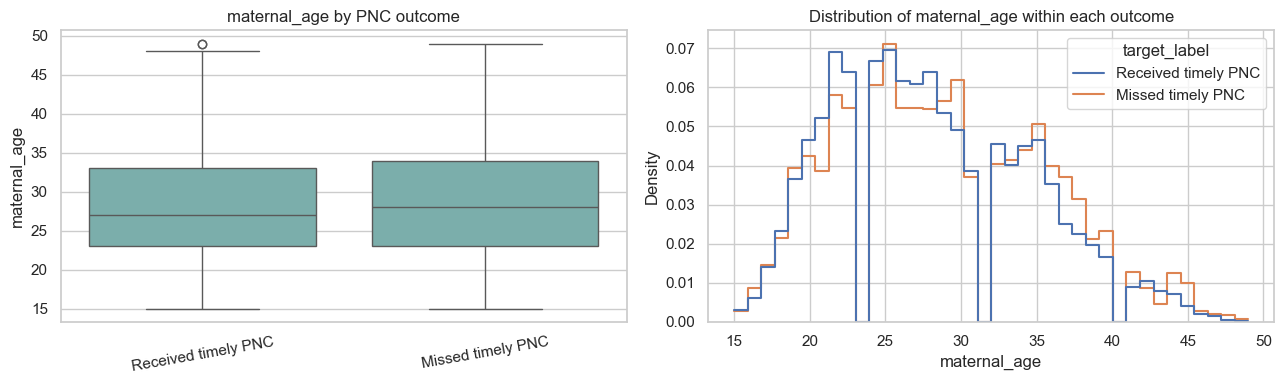

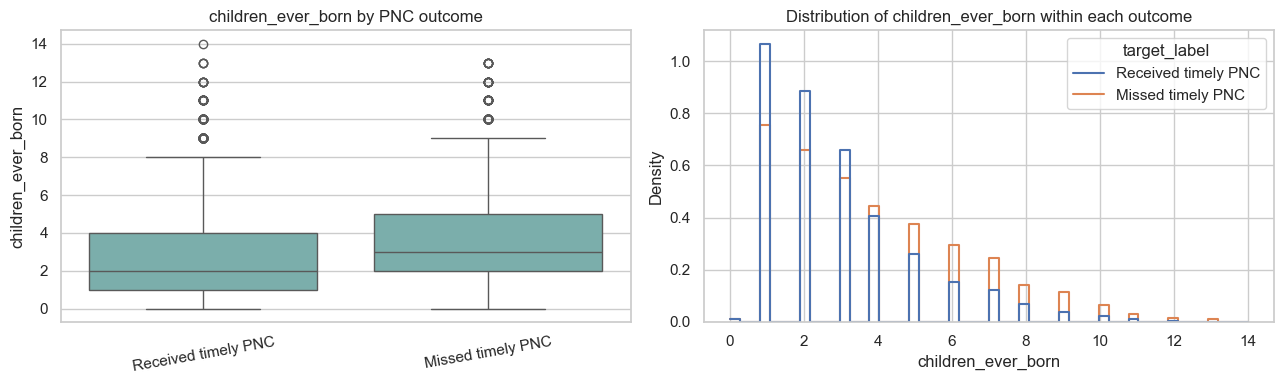

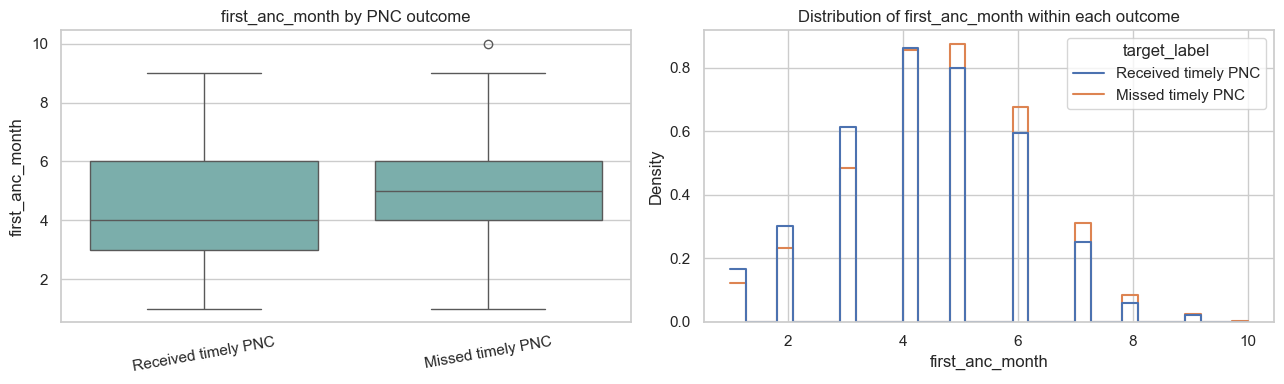

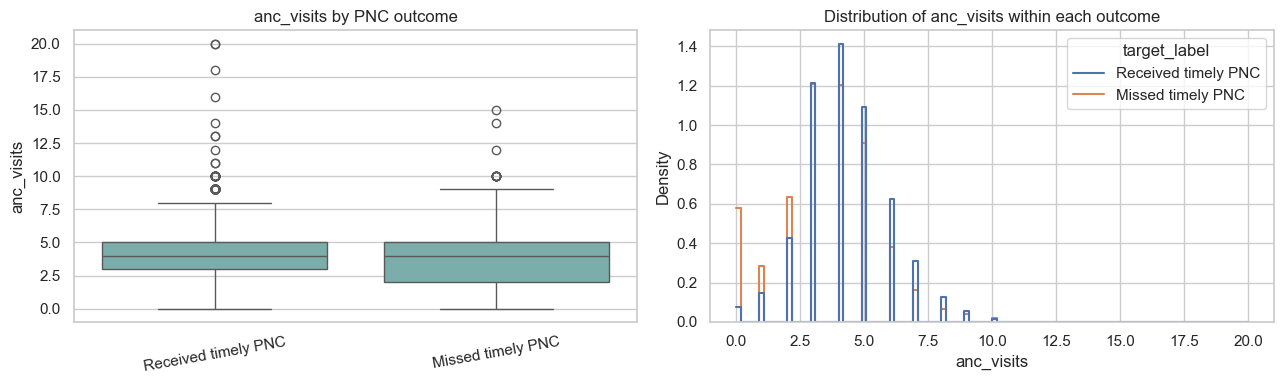

In [13]:
grouped_numeric = df.groupby(TARGET)[numeric_features].agg(["count", "mean", "median", "std"])
grouped_numeric.index = grouped_numeric.index.map(TARGET_LABELS)
display(grouped_numeric)

for feature in numeric_features:
    plot_data = df.assign(target_label=df[TARGET].map(TARGET_LABELS))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.boxplot(data=plot_data, x="target_label", y=feature, color="#72B7B2", ax=axes[0])
    axes[0].set(title=f"{feature} by PNC outcome", xlabel="")
    axes[0].tick_params(axis="x", rotation=10)
    sns.histplot(data=plot_data, x=feature, hue="target_label", stat="density",
                 common_norm=False, element="step", fill=False, ax=axes[1])
    axes[1].set_title(f"Distribution of {feature} within each outcome")
    plt.tight_layout()
    plt.show()

,age_group,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,15–19,791,210,0.265,0.236,1.000,696.342,0.257
1,20–24,2698,613,0.227,0.212,1.000,"2,525.910",0.206
2,25–29,2866,702,0.245,0.230,1.000,"2,741.591",0.210
3,30–34,2068,541,0.262,0.243,1.000,"1,857.921",0.200
4,35–39,1477,434,0.294,0.271,1.000,"1,193.978",0.231
5,40–49,605,191,0.316,0.280,1.000,523.799,0.248


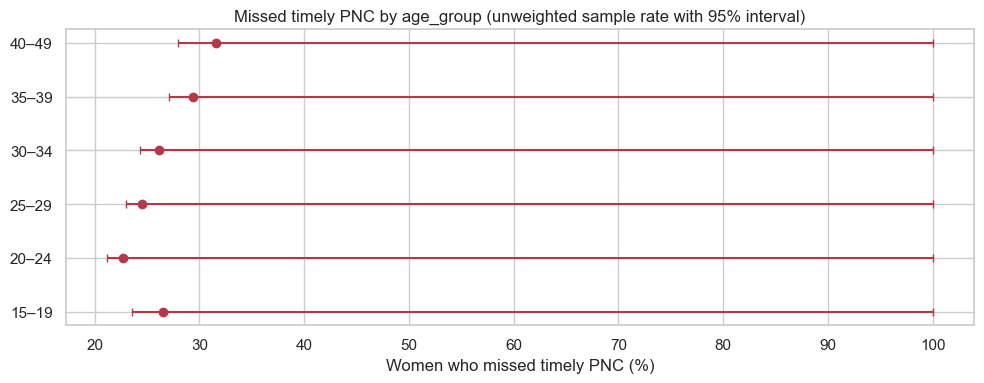

,children_group,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,0–1,2819,555,0.197,0.183,1.000,"2,856.839",0.187
1,2–3,4136,878,0.212,0.200,1.000,"3,998.796",0.189
2,4–5,1998,595,0.298,0.278,1.000,"1,717.933",0.244
3,6+,1552,663,0.427,0.403,1.000,965.972,0.354


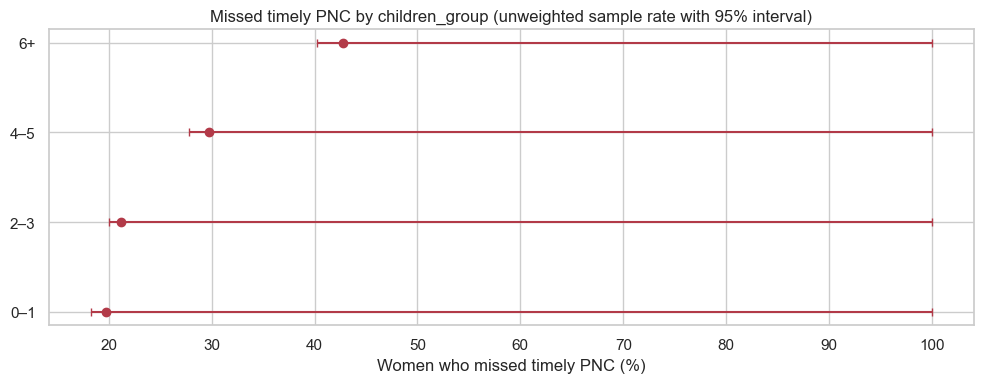

,anc_visit_group,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,0,389,283,0.728,0.681,1.000,192.315,0.586
1,1–3,3574,1041,0.291,0.277,1.000,"2,932.613",0.255
2,4–7,6177,1300,0.210,0.200,1.000,"5,996.992",0.187
3,8+,355,63,0.177,0.141,1.000,404.670,0.168


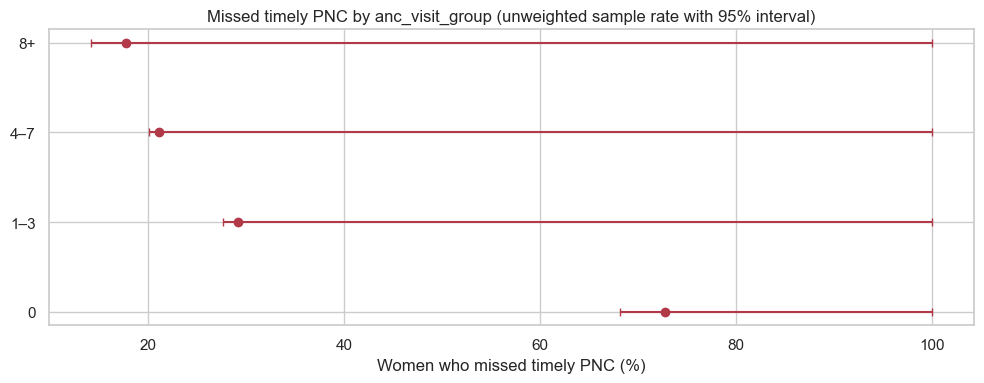

,anc_trimester,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,First trimester,2818,550,0.195,0.181,1.000,"2,896.357",0.171
1,Second trimester,6311,1579,0.250,0.240,1.000,"5,615.914",0.217
2,Third trimester,979,277,0.283,0.256,1.000,829.428,0.268


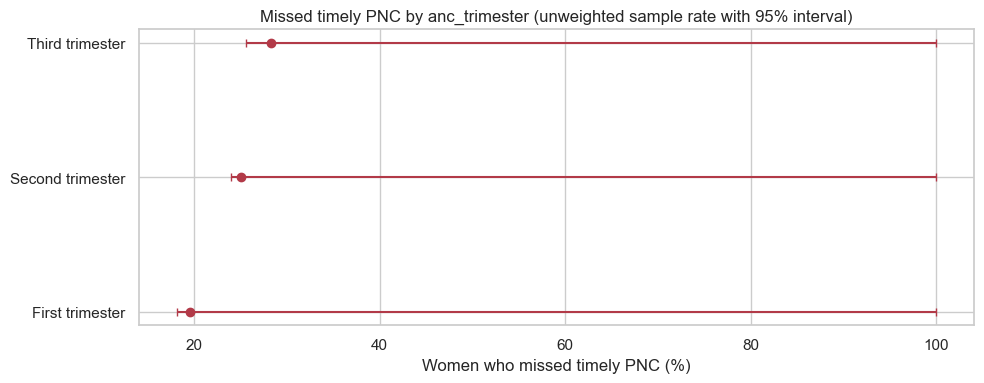

In [14]:
# Readable bands for rate plots only.
binned = df.copy()
binned["age_group"] = pd.cut(
    binned["maternal_age"], bins=[14, 19, 24, 29, 34, 39, 49],
    labels=["15–19", "20–24", "25–29", "30–34", "35–39", "40–49"]
)
binned["children_group"] = pd.cut(
    binned["children_ever_born"], bins=[-1, 1, 3, 5, np.inf],
    labels=["0–1", "2–3", "4–5", "6+"]
)
binned["anc_visit_group"] = pd.cut(
    binned["anc_visits"], bins=[-1, 0, 3, 7, np.inf],
    labels=["0", "1–3", "4–7", "8+"]
)
binned["anc_trimester"] = pd.cut(
    binned["first_anc_month"], bins=[0, 3, 6, 10],
    labels=["First trimester", "Second trimester", "Third trimester"]
)

for feature in ["age_group", "children_group", "anc_visit_group", "anc_trimester"]:
    table = target_rate_table(binned, feature)
    display(table)
    plot_rate_table(table, feature, f"Missed timely PNC by {feature}", sort=False)

## 11. Categorical predictors compared with the target

For each category, the notebook reports the number of women, number who missed timely PNC, missed-care rate, and a 95% Wilson interval. Rates are more informative than raw missed counts when category sizes differ.


pregnancy_outcome


,pregnancy_outcome,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Live birth,10363,2638,0.255,0.246,1.000,"9,414.154",0.213
1,Stillbirth,142,53,0.373,0.298,1.000,125.386,0.373


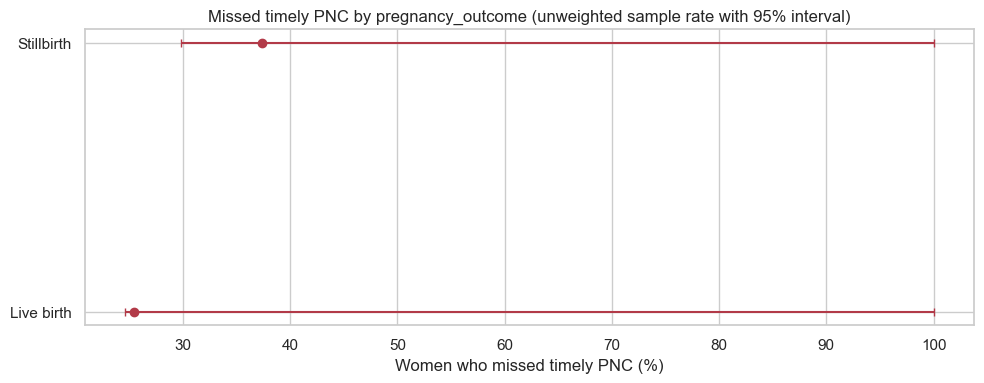


residence


,residence,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Urban,3635,683,0.188,0.176,1.000,"3,569.071",0.157
1,Rural,6870,2008,0.292,0.282,1.000,"5,970.469",0.250


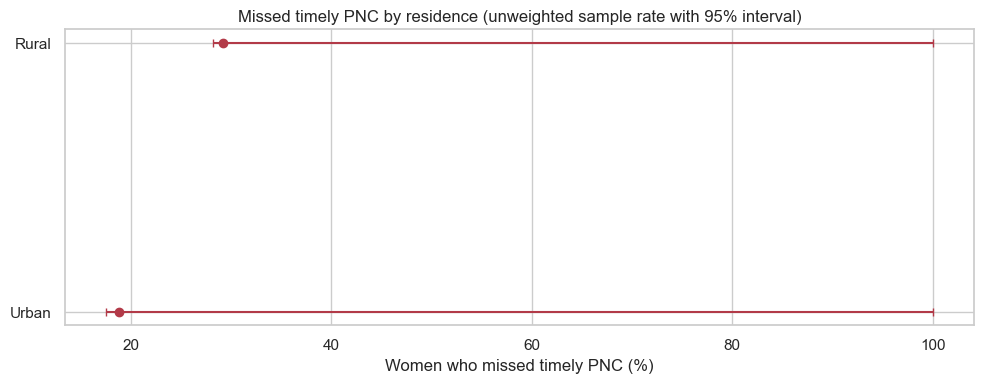


education_level


,education_level,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,No education,2124,1103,0.519,0.498,1.000,857.291,0.452
1,Primary,3548,868,0.245,0.231,1.000,"3,396.198",0.250
2,Secondary,3302,549,0.166,0.154,1.000,"3,471.968",0.175
3,Higher,1531,171,0.112,0.097,1.000,"1,814.083",0.116


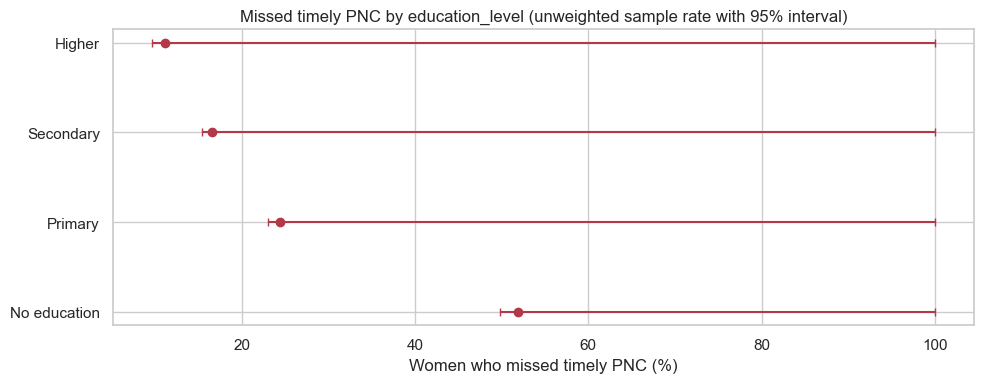


wealth_quintile


,wealth_quintile,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Poorest,3289,1409,0.428,0.412,1.000,"2,059.042",0.365
1,Poorer,1775,416,0.234,0.215,1.000,"1,688.339",0.234
2,Middle,1841,345,0.187,0.170,1.000,"1,689.842",0.193
3,Richer,2064,367,0.178,0.162,1.000,"2,015.192",0.185
4,Richest,1536,154,0.100,0.086,1.000,"2,087.125",0.099


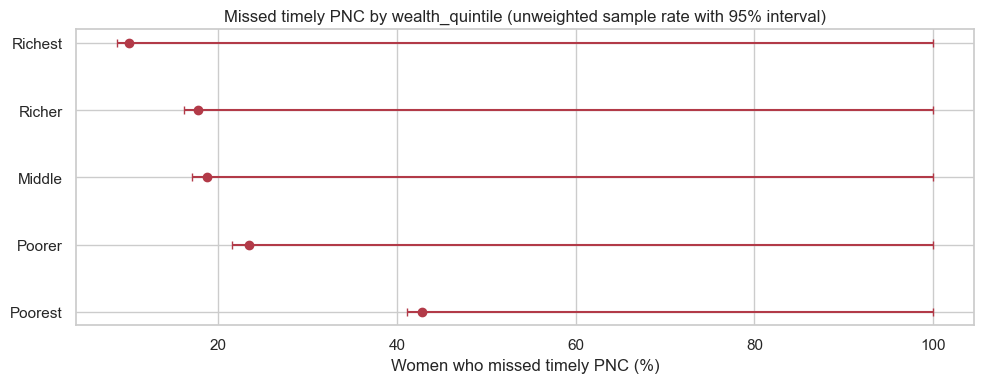


marital_status


,marital_status,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Divorced,132,48,0.364,0.287,1.000,88.726,0.274
1,Living with partner,814,202,0.248,0.220,1.000,975.622,0.276
2,Married,7690,2051,0.267,0.257,1.000,"6,544.597",0.212
3,Never married,1100,213,0.194,0.171,1.000,"1,166.264",0.181
4,Separated,602,123,0.204,0.174,1.000,628.213,0.193
5,Widowed,167,54,0.323,0.257,1.000,136.118,0.297


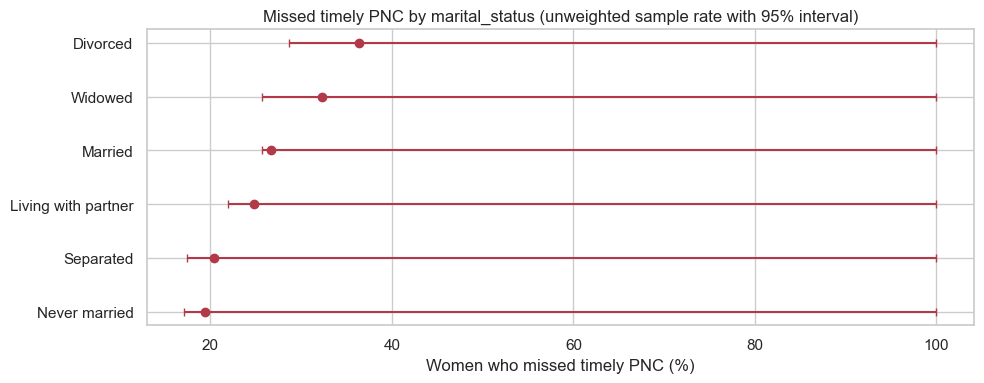


currently_working


,currently_working,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,No,6045,1828,0.302,0.291,1.000,"4,924.731",0.236
1,Yes,4460,863,0.193,0.182,1.000,"4,614.809",0.193


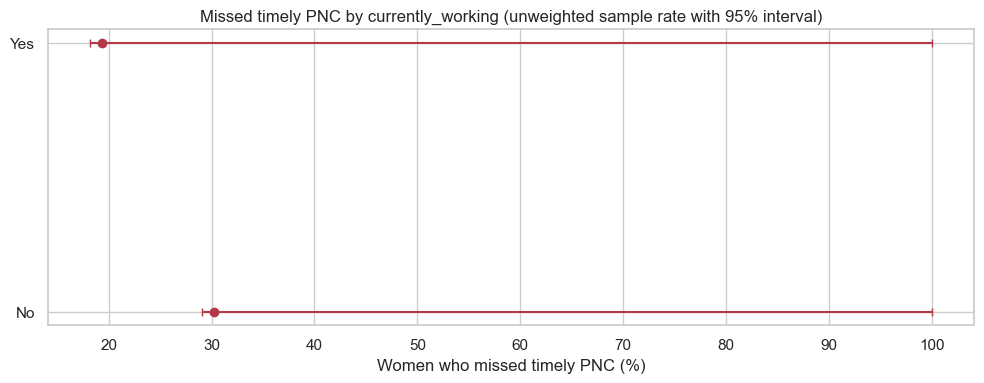


pregnancy_intention


,pregnancy_intention,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Wanted then,6823,1867,0.274,0.263,1.000,"5,761.482",0.209
1,Wanted later,2858,632,0.221,0.206,1.000,"2,911.912",0.223
2,Wanted no more,824,192,0.233,0.205,1.000,866.146,0.228


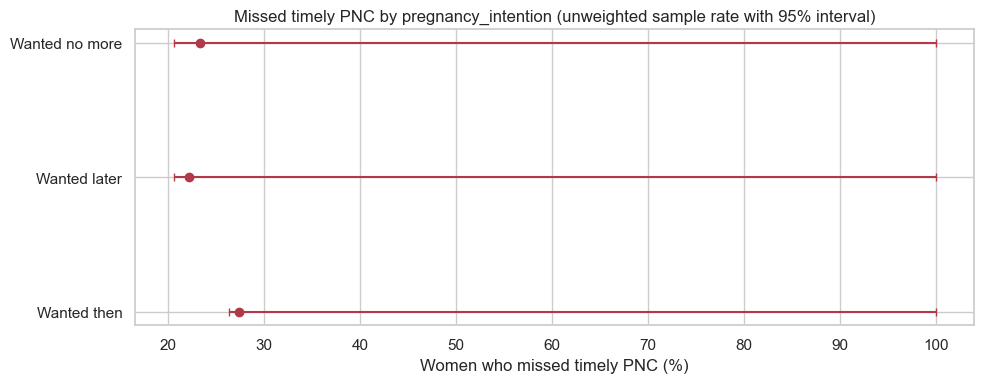


delivery_place


,delivery_place,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Faith-based/NGO facility,528,48,0.091,0.069,1.000,546.775,0.100
1,Home,1930,1328,0.688,0.667,1.000,"1,060.142",0.644
2,Other,58,24,0.414,0.296,1.000,51.021,0.359
3,Private facility,1284,158,0.123,0.106,1.000,"1,656.017",0.136
4,Public facility,6705,1133,0.169,0.160,1.000,"6,225.584",0.172


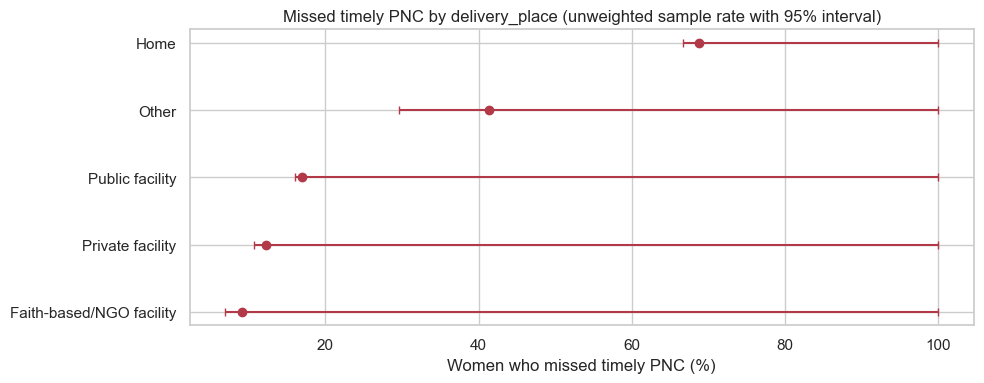


caesarean_delivery


,caesarean_delivery,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,No,9082,2578,0.284,0.275,1.000,"7,946.239",0.244
1,Yes,1423,113,0.079,0.066,1.000,"1,593.301",0.071


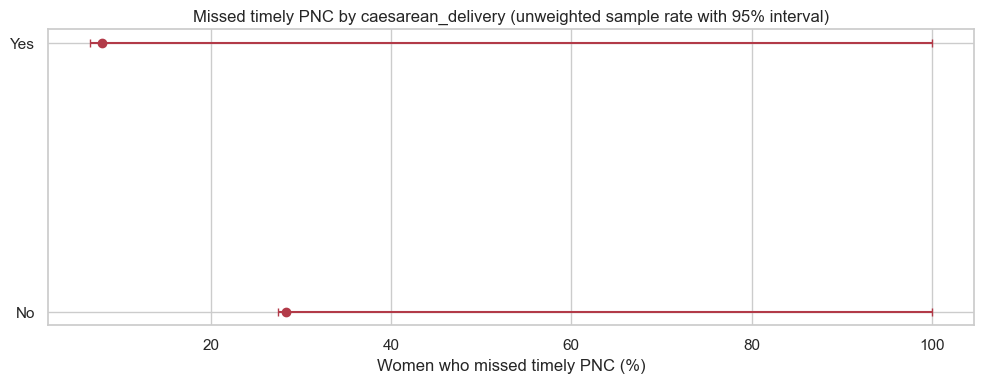

In [15]:
categorical_rate_tables = {}
for feature in [column for column in categorical_features if column != "county_name"]:
    order = ordered_categories.get(feature)
    table = target_rate_table(df, feature, order=order)
    categorical_rate_tables[feature] = table
    print(f"\n{feature}")
    display(table)
    plot_rate_table(
        table,
        feature,
        f"Missed timely PNC by {feature}",
        sort=(order is None),
    )

## 12. County-level analysis

County results include sample size, missed-care count, sample rate, and uncertainty interval. Small samples generally produce wider intervals. Because survey weights are unavailable, rankings describe this modelling sample and should not be presented as official county prevalence estimates.

,county_name,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Garissa,267,177,0.663,0.604,1.000,107.693,0.556
1,Wajir,306,193,0.631,0.575,1.000,67.308,0.647
2,Marsabit,278,166,0.597,0.539,1.000,69.998,0.601
3,Mandera,399,214,0.536,0.487,1.000,112.463,0.532
4,Tana River,307,121,0.394,0.341,1.000,70.996,0.381
5,Bungoma,252,93,0.369,0.312,1.000,325.681,0.402
6,Kakamega,231,85,0.368,0.308,1.000,379.359,0.383
7,Samburu,313,106,0.339,0.288,1.000,81.118,0.358
8,Turkana,309,102,0.330,0.280,1.000,160.659,0.333
9,Meru,174,54,0.310,0.246,1.000,277.774,0.367


Highest sample missed-PNC rates:


,county_name,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
0,Garissa,267,177,0.663,0.604,1.000,107.693,0.556
1,Wajir,306,193,0.631,0.575,1.000,67.308,0.647
2,Marsabit,278,166,0.597,0.539,1.000,69.998,0.601
3,Mandera,399,214,0.536,0.487,1.000,112.463,0.532
4,Tana River,307,121,0.394,0.341,1.000,70.996,0.381
5,Bungoma,252,93,0.369,0.312,1.000,325.681,0.402
6,Kakamega,231,85,0.368,0.308,1.000,379.359,0.383
7,Samburu,313,106,0.339,0.288,1.000,81.118,0.358
8,Turkana,309,102,0.330,0.280,1.000,160.659,0.333
9,Meru,174,54,0.310,0.246,1.000,277.774,0.367


Lowest sample missed-PNC rates:


,county_name,women,missed,missed_rate,ci_low,ci_high,weight_sum,weighted_missed_rate
46,Kirinyaga,139,10,0.072,0.040,1.000,105.882,0.063
45,Busia,244,18,0.074,0.047,1.000,190.033,0.080
44,Embu,145,11,0.076,0.043,1.000,91.944,0.082
43,Kisumu,244,21,0.086,0.057,1.000,246.920,0.089
42,Machakos,157,14,0.089,0.054,1.000,225.119,0.091
41,Vihiga,178,16,0.090,0.056,1.000,91.054,0.096
40,Nyamira,140,14,0.100,0.061,1.000,72.678,0.095
39,Elgeyo-Marakwet,210,22,0.105,0.070,1.000,87.061,0.111
38,Kwale,226,24,0.106,0.072,1.000,162.751,0.104
37,Kiambu,192,23,0.120,0.081,1.000,600.002,0.126


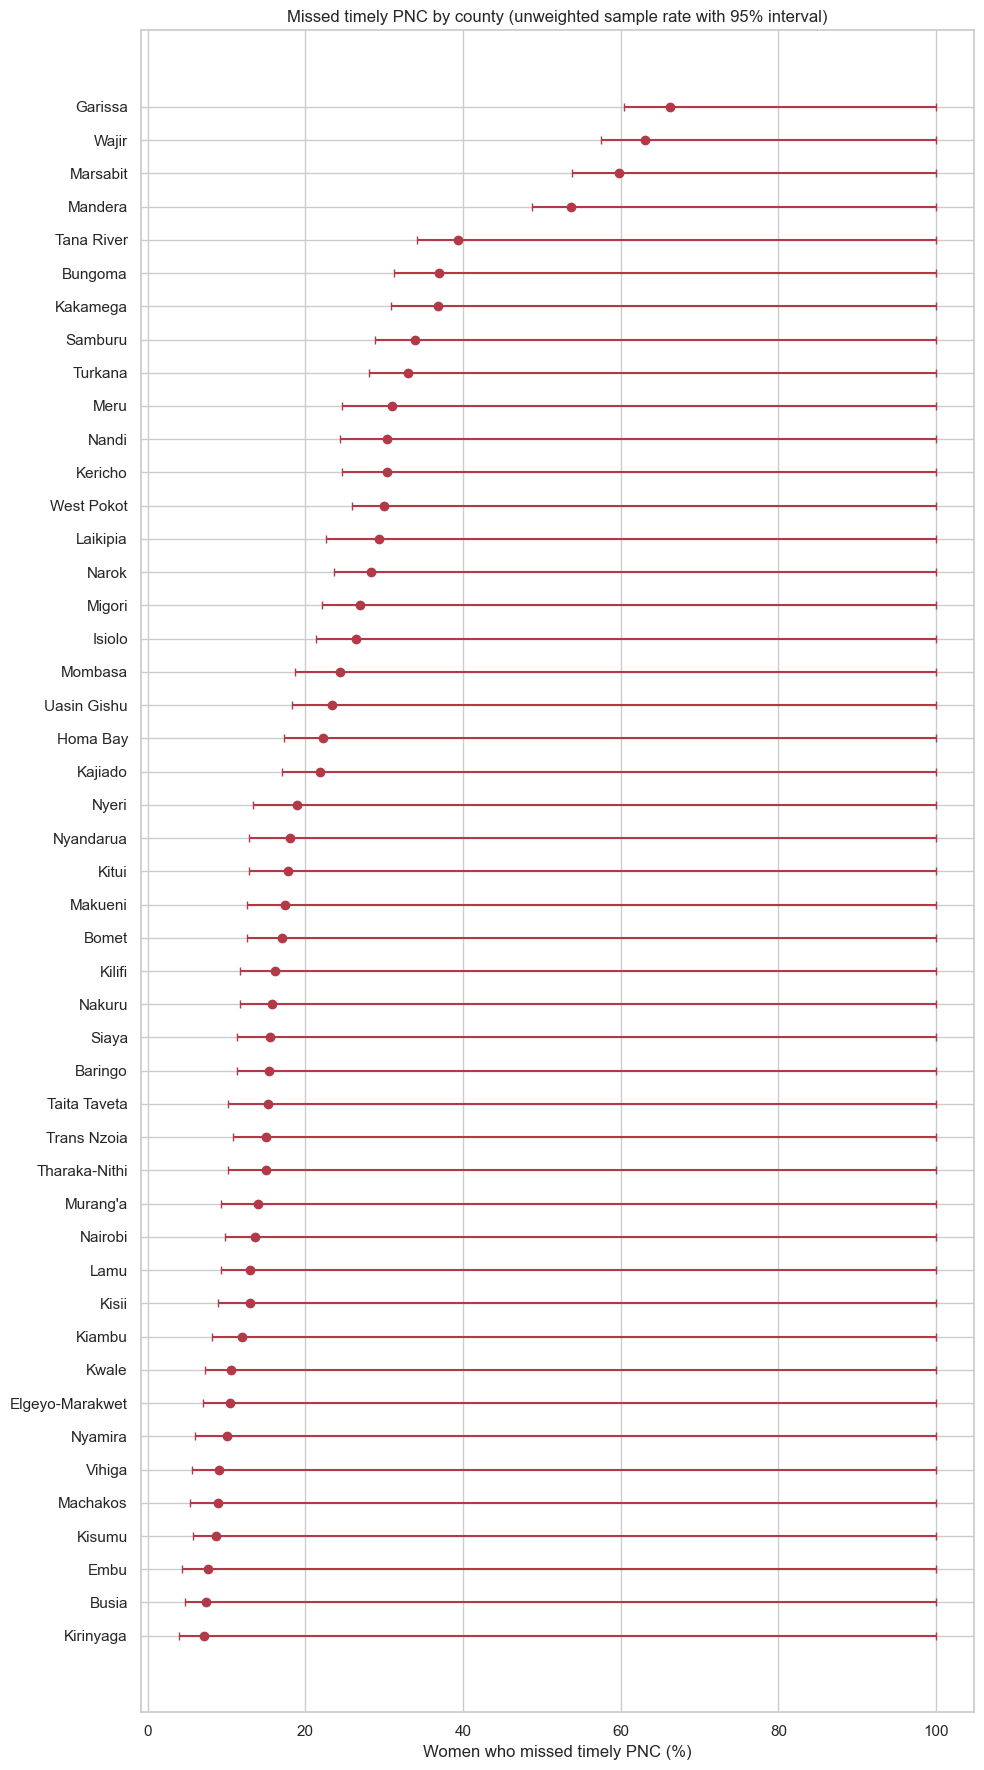

In [16]:
county_rates = target_rate_table(df, "county_name")
county_rates = county_rates.sort_values("missed_rate", ascending=False).reset_index(drop=True)
display(county_rates)

print("Highest sample missed-PNC rates:")
display(county_rates.head(10))
print("Lowest sample missed-PNC rates:")
display(county_rates.tail(10).sort_values("missed_rate"))

plot_rate_table(county_rates, "county_name", "Missed timely PNC by county", sort=True)

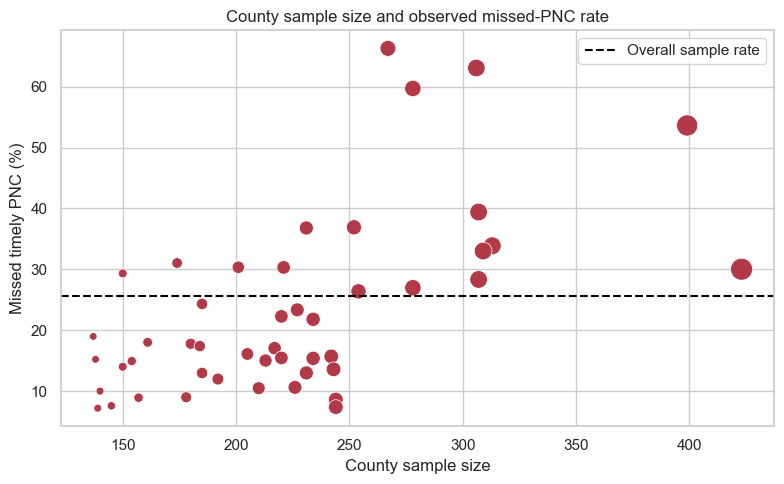

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=county_rates, x="women", y=county_rates["missed_rate"] * 100,
                size="women", sizes=(30, 250), color="#B23A48", legend=False)
plt.axhline(df[TARGET].mean() * 100, color="black", linestyle="--", label="Overall sample rate")
plt.xlabel("County sample size")
plt.ylabel("Missed timely PNC (%)")
plt.title("County sample size and observed missed-PNC rate")
plt.legend()
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
cluster_id,"1,680.000",846.282,487.856,1.000,424.750,846.500,"1,268.250","1,692.000"
women,"1,680.000",6.253,3.299,1.000,4.000,6.000,8.000,19.000
missed_rate,"1,680.000",0.224,0.251,0.000,0.000,0.167,0.354,1.000
weight_sum,"1,680.000",5.678,5.716,0.117,2.105,4.062,7.504,74.028


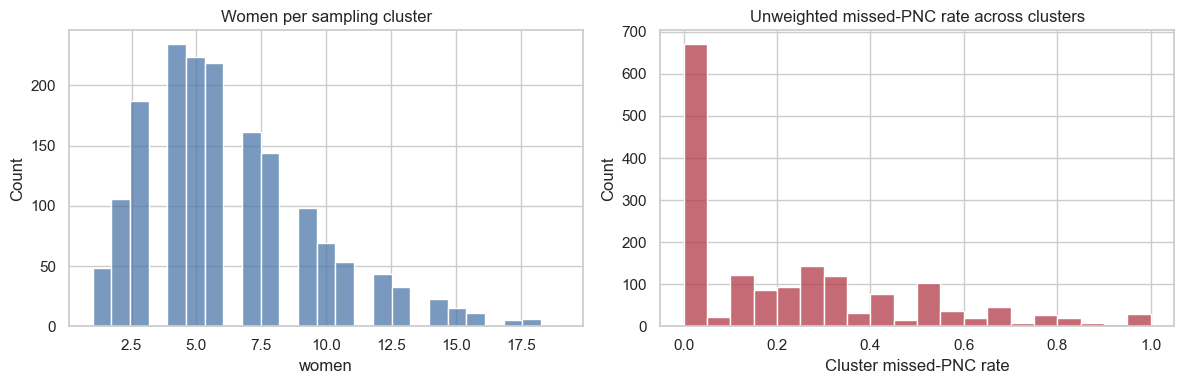

In [18]:
# Survey-design diagnostics: cluster size and cluster-level outcome variation.
cluster_summary = (
    df.groupby("cluster_id")
    .agg(women=(TARGET, "size"), missed_rate=(TARGET, "mean"), weight_sum=("sample_weight", "sum"))
    .reset_index()
)
display(cluster_summary.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=cluster_summary, x="women", bins=25, ax=axes[0], color="#4C78A8")
axes[0].set_title("Women per sampling cluster")
sns.histplot(data=cluster_summary, x="missed_rate", bins=20, ax=axes[1], color="#B23A48")
axes[1].set_title("Unweighted missed-PNC rate across clusters")
axes[1].set_xlabel("Cluster missed-PNC rate")
plt.tight_layout()
plt.show()

## 13. Relationships among predictors

Spearman correlation is used for numeric variables because the count variables may be skewed. Cramér's V summarizes categorical association from 0 (little association) to 1 (strong association). These measures help identify overlapping information, but they do not by themselves require dropping a feature.

,maternal_age,children_ever_born,first_anc_month,anc_visits
maternal_age,1.000,0.722,0.033,-0.004
children_ever_born,0.722,1.000,0.141,-0.161
first_anc_month,0.033,0.141,1.000,-0.716
anc_visits,-0.004,-0.161,-0.716,1.000


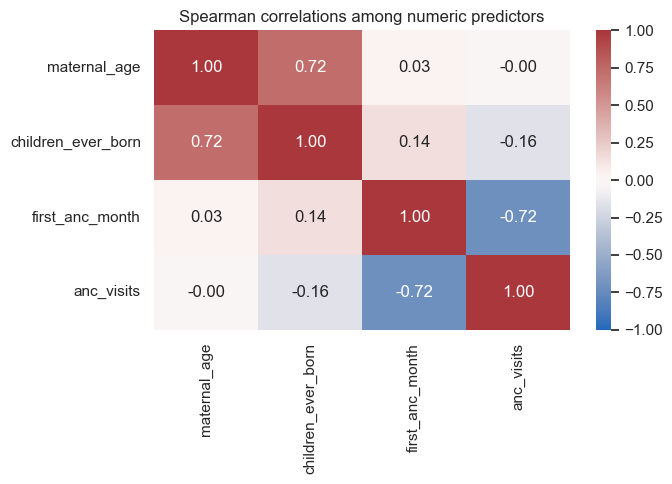

In [19]:
spearman = df[numeric_features].corr(method="spearman")
display(spearman)

plt.figure(figsize=(7, 5))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Spearman correlations among numeric predictors")
plt.tight_layout()
plt.show()

,pregnancy_outcome,county_name,residence,education_level,wealth_quintile,marital_status,currently_working,pregnancy_intention,delivery_place,caesarean_delivery
pregnancy_outcome,1.000,0.029,0.016,0.012,0.000,0.033,0.000,0.002,0.014,0.000
county_name,0.029,1.000,0.351,0.433,0.309,0.192,0.388,0.225,0.278,0.209
residence,0.016,0.351,1.000,0.257,0.656,0.069,0.080,0.046,0.253,0.124
education_level,0.012,0.433,0.257,1.000,0.391,0.154,0.302,0.196,0.322,0.247
wealth_quintile,0.000,0.309,0.656,0.391,1.000,0.063,0.237,0.115,0.262,0.247
marital_status,0.033,0.192,0.069,0.154,0.063,1.000,0.113,0.250,0.056,0.028
currently_working,0.000,0.388,0.080,0.302,0.237,0.113,1.000,0.100,0.195,0.073
pregnancy_intention,0.002,0.225,0.046,0.196,0.115,0.250,0.100,1.000,0.077,0.045
delivery_place,0.014,0.278,0.253,0.322,0.262,0.056,0.195,0.077,1.000,0.236
caesarean_delivery,0.000,0.209,0.124,0.247,0.247,0.028,0.073,0.045,0.236,1.000


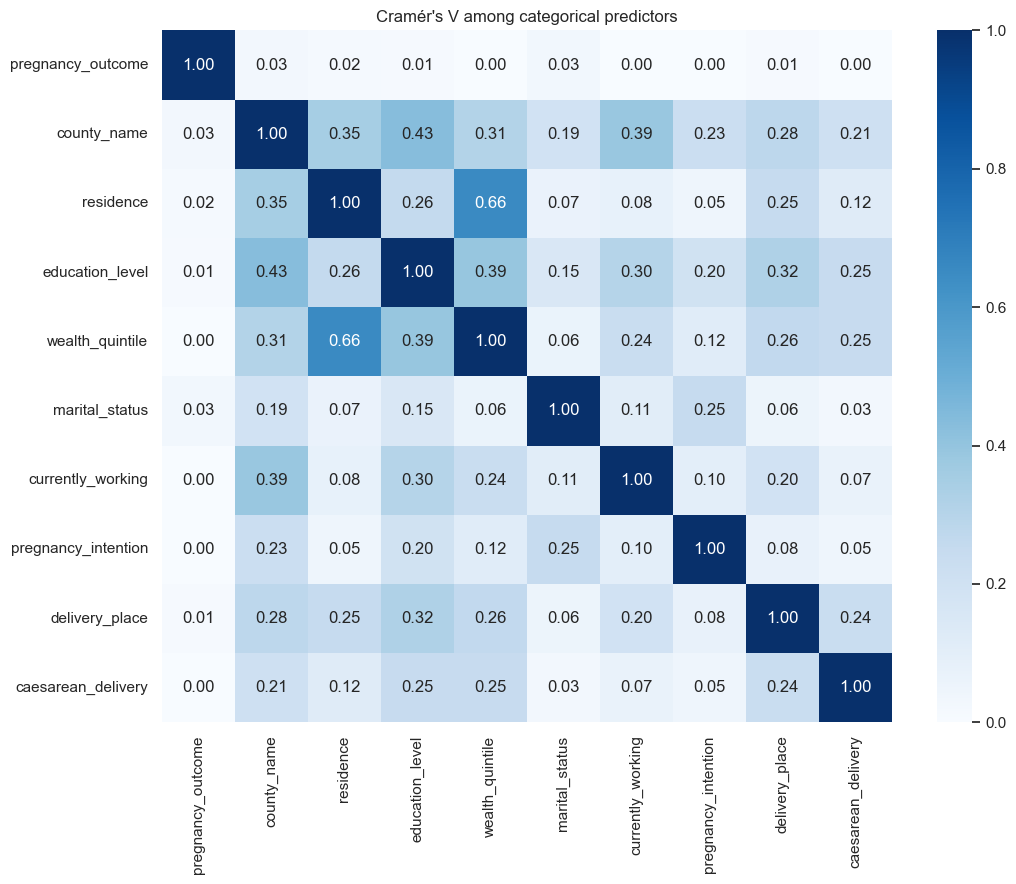

In [20]:
cramers_matrix = pd.DataFrame(
    np.eye(len(categorical_features)),
    index=categorical_features,
    columns=categorical_features,
)
for first in categorical_features:
    for second in categorical_features:
        if first != second:
            cross_table = pd.crosstab(df[first], df[second])
            cramers_matrix.loc[first, second] = cramers_v(cross_table)

display(cramers_matrix)
plt.figure(figsize=(11, 9))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Cramér's V among categorical predictors")
plt.tight_layout()
plt.show()

In [21]:
# Focused cross-tabulations for relationships expected to matter operationally.
relationship_pairs = [
    ("education_level", "wealth_quintile"),
    ("wealth_quintile", "residence"),
    ("delivery_place", "caesarean_delivery"),
    ("education_level", "residence"),
]
for row_feature, column_feature in relationship_pairs:
    print(f"\nRow percentages: {row_feature} by {column_feature}")
    display(pd.crosstab(
        df[row_feature], df[column_feature], normalize="index"
    ).mul(100).round(1))


Row percentages: education_level by wealth_quintile


wealth_quintile,Middle,Poorer,Poorest,Richer,Richest
education_level,,,,,
Higher,14.400,6.000,1.500,30.000,48.000
No education,7.500,7.600,77.500,6.200,1.200
Primary,19.800,24.600,33.800,16.000,5.900
Secondary,23.000,19.700,12.800,27.400,17.200



Row percentages: wealth_quintile by residence


residence,Rural,Urban
wealth_quintile,,
Middle,72.400,27.600
Poorer,88.300,11.700
Poorest,93.600,6.400
Richer,36.400,63.600
Richest,9.200,90.800



Row percentages: delivery_place by caesarean_delivery


caesarean_delivery,No,Yes
delivery_place,,
Faith-based/NGO facility,78.200,21.800
Home,100.000,0.000
Other,100.000,0.000
Private facility,71.500,28.500
Public facility,86.000,14.000



Row percentages: education_level by residence


residence,Rural,Urban
education_level,,
Higher,40.600,59.400
No education,78.200,21.800
Primary,73.000,27.000
Secondary,60.500,39.500


## 14. Exploratory statistical associations and effect sizes

### Categorical predictors

For each categorical predictor:

- a chi-square test asks whether the predictor and target are statistically associated;
- Cramér's V describes the strength of that association.

### Numeric predictors

For each numeric predictor:

- the Mann–Whitney U test compares distributions without assuming normality;
- rank-biserial correlation gives an effect size;
- the median and mean difference show the direction and practical size of the difference.

With more than 10,000 observations, small differences can have small p-values. Effect size and practical meaning are therefore more important than significance alone. These unadjusted tests do not establish causality.

In [22]:
categorical_tests = []
for feature in categorical_features:
    table = pd.crosstab(df[feature], df[TARGET])
    chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(table)
    categorical_tests.append({
        "feature": feature,
        "chi_square": chi2,
        "degrees_freedom": degrees_freedom,
        "p_value": p_value,
        "cramers_v": cramers_v(table),
        "minimum_expected_count": expected.min(),
        "cells_expected_below_5": int((expected < 5).sum()),
    })

categorical_tests = pd.DataFrame(categorical_tests).sort_values("cramers_v", ascending=False)
display(categorical_tests)

,feature,chi_square,degrees_freedom,p_value,cramers_v,minimum_expected_count,cells_expected_below_5
8,delivery_place,"2,359.703",4,0.000,0.474,14.857,0
1,county_name,"1,328.109",46,0.000,0.349,35.094,0
3,education_level,"1,082.082",3,0.000,0.321,392.187,0
4,wealth_quintile,824.591,4,0.000,0.280,393.467,0
9,caesarean_delivery,268.803,1,0.000,0.160,364.521,0
6,currently_working,159.165,1,0.000,0.123,"1,142.490",0
2,residence,135.405,1,0.000,0.113,931.155,0
5,marital_status,47.783,5,0.000,0.064,33.814,0
7,pregnancy_intention,31.652,2,0.000,0.053,211.079,0
0,pregnancy_outcome,9.741,1,0.002,0.030,36.375,0


In [23]:
numeric_tests = []
for feature in numeric_features:
    timely = df.loc[df[TARGET] == 0, feature].dropna()
    missed = df.loc[df[TARGET] == 1, feature].dropna()
    statistic, p_value = stats.mannwhitneyu(missed, timely, alternative="two-sided")
    # Positive rank-biserial values indicate generally higher values in the missed group.
    rank_biserial = (2 * statistic) / (len(missed) * len(timely)) - 1
    numeric_tests.append({
        "feature": feature,
        "timely_n": len(timely),
        "missed_n": len(missed),
        "timely_median": timely.median(),
        "missed_median": missed.median(),
        "mean_difference_missed_minus_timely": missed.mean() - timely.mean(),
        "mann_whitney_u": statistic,
        "p_value": p_value,
        "rank_biserial_effect": rank_biserial,
    })

numeric_tests = pd.DataFrame(numeric_tests).sort_values(
    "rank_biserial_effect", key=lambda values: values.abs(), ascending=False
)
display(numeric_tests)

,feature,timely_n,missed_n,timely_median,missed_median,mean_difference_missed_minus_timely,mann_whitney_u,p_value,rank_biserial_effect
3,anc_visits,7808,2687,4.000,4.000,-0.779,"8,142,130.500",0.000,-0.224
1,children_ever_born,7814,2691,2.000,3.000,0.935,"12,726,149.000",0.000,0.210
2,first_anc_month,7702,2406,4.000,5.000,0.255,"10,097,967.500",0.000,0.090
0,maternal_age,7814,2691,27.000,28.000,0.737,"11,151,022.000",0.000,0.061


### Exploratory univariate odds ratios

The following simple logistic regressions estimate one predictor at a time. Numeric odds ratios represent a one-unit increase. Categorical odds ratios compare each category with an explicitly reported reference category. They are **unadjusted**, so they may reflect confounding by other characteristics.

In [24]:
try:
    import statsmodels.api as sm

    odds_ratio_rows = []

    for feature in numeric_features:
        analysis = df[[feature, TARGET]].dropna()
        design = sm.add_constant(analysis[[feature]], has_constant="add")
        fitted = sm.Logit(analysis[TARGET], design).fit(disp=False)
        estimate = fitted.params[feature]
        interval = fitted.conf_int().loc[feature]
        odds_ratio_rows.append({
            "feature": feature,
            "comparison": "Per one-unit increase",
            "reference": "Not applicable",
            "odds_ratio": np.exp(estimate),
            "ci_low": np.exp(interval.iloc[0]),
            "ci_high": np.exp(interval.iloc[1]),
            "p_value": fitted.pvalues[feature],
        })

    for feature in categorical_features:
        analysis = df[[feature, TARGET]].dropna().copy()
        categories = ordered_categories.get(feature, sorted(analysis[feature].unique()))
        reference = categories[0]
        analysis[feature] = pd.Categorical(analysis[feature], categories=categories)
        design = pd.get_dummies(analysis[feature], prefix=feature, drop_first=True, dtype=float)
        design = sm.add_constant(design, has_constant="add")
        fitted = sm.Logit(analysis[TARGET], design).fit(disp=False, maxiter=200)
        intervals = fitted.conf_int()
        for column in design.columns[1:]:
            comparison = column.replace(f"{feature}_", "")
            odds_ratio_rows.append({
                "feature": feature,
                "comparison": comparison,
                "reference": reference,
                "odds_ratio": np.exp(fitted.params[column]),
                "ci_low": np.exp(intervals.loc[column, 0]),
                "ci_high": np.exp(intervals.loc[column, 1]),
                "p_value": fitted.pvalues[column],
            })

    odds_ratios = pd.DataFrame(odds_ratio_rows)
    display(odds_ratios)
except ImportError:
    print("statsmodels is not installed, so the optional odds-ratio table was skipped.")

,feature,comparison,reference,odds_ratio,ci_low,ci_high,p_value
0,maternal_age,Per one-unit increase,Not applicable,1.017,1.010,1.024,0.000
1,children_ever_born,Per one-unit increase,Not applicable,1.193,1.171,1.216,0.000
2,first_anc_month,Per one-unit increase,Not applicable,1.102,1.071,1.133,0.000
3,anc_visits,Per one-unit increase,Not applicable,0.776,0.755,0.796,0.000
4,pregnancy_outcome,Stillbirth,Live birth,1.744,1.238,2.457,0.001
...,...,...,...,...,...,...,...
67,delivery_place,Home,Faith-based/NGO facility,22.060,16.148,30.135,0.000
68,delivery_place,Other,Faith-based/NGO facility,7.059,3.870,12.874,0.000
69,delivery_place,Private facility,Faith-based/NGO facility,1.403,0.999,1.972,0.051
70,delivery_place,Public facility,Faith-based/NGO facility,2.033,1.501,2.754,0.000


## 15. Rare categories, outliers, and modelling-readiness checks

A category is flagged here when it has fewer than 100 women or less than 1% of the sample. The threshold is an EDA warning, not an automatic merging rule. Categories should be combined only when the grouping is substantively defensible.

In [25]:
rare_rows = []
for feature in categorical_features:
    counts = df[feature].value_counts(dropna=False)
    for category, count in counts.items():
        percent = 100 * count / len(df)
        if count < 100 or percent < 1:
            group = df.loc[df[feature].eq(category), TARGET]
            rare_rows.append({
                "feature": feature,
                "category": category,
                "women": count,
                "percent": percent,
                "missed_rate_percent": 100 * group.mean(),
            })

rare_categories = pd.DataFrame(rare_rows)
display(rare_categories.sort_values(["feature", "women"]) if not rare_categories.empty else rare_categories)

,feature,category,women,percent,missed_rate_percent
0,delivery_place,Other,58,0.552,41.379


In [26]:
leakage_names = {"m62", "m63", "m66", "m67", "pre_discharge_status", "post_discharge_status"}
identifier_names = {"woman_id", "cluster_id", "household_id", "respondent_line"}
model_features = numeric_features + categorical_features

readiness = pd.DataFrame({
    "issue": [
        "Moderate class imbalance",
        "Missing predictor values",
        "Target leakage fields present",
        "Identifier fields present",
        "High-cardinality county predictor",
        "Survey weights available",
        "Cluster identifiers available",
    ],
    "finding": [
        f"Positive class = {df[TARGET].mean():.1%}",
        f"{int(df.isna().sum().sum()):,} missing cells",
        sorted(leakage_names.intersection(model_features)),
        sorted(identifier_names.intersection(model_features)),
        f"{df['county_name'].nunique()} county categories",
        "Yes: sample_weight",
        "Yes: cluster_id",
    ],
    "modelling_response": [
        "Use stratification and evaluate PR-AUC, recall, precision, F1, and ROC-AUC.",
        "Fit imputation inside the training pipeline; consider missingness indicators.",
        "None required if the list is empty.",
        "None required if the list is empty.",
        "Use an encoder that handles unseen categories; monitor rare county levels.",
        "Use weights for descriptive estimates; decide and document how weights enter evaluation.",
        "Compare a stratified split with a cluster-grouped split to assess geographic leakage.",
    ],
})
display(readiness)

,issue,finding,modelling_response
0,Moderate class imbalance,Positive class = 25.6%,"Use stratification and evaluate PR-AUC, recall..."
1,Missing predictor values,407 missing cells,Fit imputation inside the training pipeline; c...
2,Target leakage fields present,[],None required if the list is empty.
3,Identifier fields present,[],None required if the list is empty.
4,High-cardinality county predictor,47 county categories,Use an encoder that handles unseen categories;...
5,Survey weights available,Yes: sample_weight,Use weights for descriptive estimates; decide ...
6,Cluster identifiers available,Yes: cluster_id,Compare a stratified split with a cluster-grou...


## 16. Automated findings summary, modelling implications, and limitations

The final cell turns the computed results into a reproducible summary. These are exploratory patterns that should guide—but not replace—cross-validated modelling and domain review.

In [27]:
overall_rate = df[TARGET].mean()

# Largest categorical rate ranges, excluding county so it does not dominate the summary.
rate_spreads = []
for feature, table in categorical_rate_tables.items():
    highest = table.loc[table["missed_rate"].idxmax()]
    lowest = table.loc[table["missed_rate"].idxmin()]
    rate_spreads.append({
        "feature": feature,
        "highest_category": highest[feature],
        "highest_rate": highest["missed_rate"],
        "lowest_category": lowest[feature],
        "lowest_rate": lowest["missed_rate"],
        "rate_gap": highest["missed_rate"] - lowest["missed_rate"],
    })
rate_spreads = pd.DataFrame(rate_spreads).sort_values("rate_gap", ascending=False)

top_county = county_rates.iloc[0]
bottom_county = county_rates.iloc[-1]
strongest_categorical = categorical_tests.iloc[0]
strongest_numeric = numeric_tests.iloc[0]

print("EDA FINDINGS")
print("============")
print(f"1. The file contains {len(df):,} rows, {len(numeric_features) + len(categorical_features)} candidate predictors, "
      f"and {len(analysis_fields)} analysis-only fields.")
print(f"2. {overall_rate:.1%} of the unweighted sample missed timely PNC; the survey-weighted estimate is "
      f"{weighted_target_rate:.1%}; the unweighted majority baseline is {1-overall_rate:.1%}.")
print(f"3. Missingness is concentrated in first_anc_month ({df['first_anc_month'].isna().mean():.2%}); "
      f"anc_visits is missing for {df['anc_visits'].isna().mean():.2%}.")
print(f"4. The strongest categorical association by Cramer's V is {strongest_categorical['feature']} "
      f"(V={strongest_categorical['cramers_v']:.3f}).")
print(f"5. The largest numeric rank-biserial effect is for {strongest_numeric['feature']} "
      f"(effect={strongest_numeric['rank_biserial_effect']:.3f}).")
print(f"6. The widest non-county sample rate gap is for {rate_spreads.iloc[0]['feature']}: "
      f"{rate_spreads.iloc[0]['lowest_category']} ({rate_spreads.iloc[0]['lowest_rate']:.1%}) versus "
      f"{rate_spreads.iloc[0]['highest_category']} ({rate_spreads.iloc[0]['highest_rate']:.1%}).")
print(f"7. County sample rates range from {bottom_county['county_name']} ({bottom_county['missed_rate']:.1%}, "
      f"n={int(bottom_county['women'])}) to {top_county['county_name']} ({top_county['missed_rate']:.1%}, "
      f"n={int(top_county['women'])}).")

print("\nMODELLING IMPLICATIONS")
print("======================")
print("- Split before preprocessing and stratify on the target.")
print("- Compare ordinary stratified splitting with a group split based on cluster_id; never use cluster_id as a predictor.")
print("- Keep sample_weight for weighted descriptions/evaluation, but do not use it as an ordinary predictor.")
print("- Fit numeric imputation and categorical encoding only on training folds.")
print("- Consider explicit missingness indicators for ANC fields.")
print("- Use an encoder that safely handles unseen categories, especially county.")
print("- Compare a simple interpretable baseline with the proposed tree-based model.")
print("- Prioritize PR-AUC and recall, while reporting precision, F1, ROC-AUC, confusion matrix, and calibration.")
print("- Tune the classification threshold using validation data and operational follow-up capacity.")
print("- Examine interactions such as residence × county, education × wealth, ANC timing × visits, "
      "delivery place × caesarean delivery, and age × children ever born.")
print("- Explain the final model globally and per person, but do not interpret SHAP values as causal effects.")

print("\nLIMITATIONS")
print("===========")
print("- Survey weights are available, but the strata variable is absent; confidence intervals shown for category rates are unweighted.")
print("- Weighted descriptive estimates improve representativeness but do not constitute a full complex-survey analysis.")
print("- Woman identifiers were removed, so identical rows cannot be verified as duplicate people.")
print("- EDA associations may be confounded and do not demonstrate causality.")
print("- County estimates with smaller samples have greater uncertainty.")
print("- Self-reported care and timing can contain recall or reporting error.")

EDA FINDINGS
1. The file contains 10,505 rows, 14 candidate predictors, and 3 analysis-only fields.
2. 25.6% of the unweighted sample missed timely PNC; the survey-weighted estimate is 21.5%; the unweighted majority baseline is 74.4%.
3. Missingness is concentrated in first_anc_month (3.78%); anc_visits is missing for 0.10%.
4. The strongest categorical association by Cramer's V is delivery_place (V=0.474).
5. The largest numeric rank-biserial effect is for anc_visits (effect=-0.224).
6. The widest non-county sample rate gap is for delivery_place: Faith-based/NGO facility (9.1%) versus Home (68.8%).
7. County sample rates range from Kirinyaga (7.2%, n=139) to Garissa (66.3%, n=267).

MODELLING IMPLICATIONS
- Split before preprocessing and stratify on the target.
- Compare ordinary stratified splitting with a group split based on cluster_id; never use cluster_id as a predictor.
- Keep sample_weight for weighted descriptions/evaluation, but do not use it as an ordinary predictor.
- Fit n

## EDA completion checklist

- [x] Dataset loaded and validated
- [x] Variables classified
- [x] Target distribution examined
- [x] Missingness analysed overall and against the target
- [x] Every numeric predictor examined alone and against the target
- [x] Every categorical predictor examined alone and against the target
- [x] County rates, sample sizes, and uncertainty reviewed
- [x] Numeric and categorical predictor relationships checked
- [x] Statistical tests and effect sizes calculated
- [x] Exploratory univariate odds ratios calculated
- [x] Rare categories and potential outliers flagged
- [x] Leakage and modelling-readiness checks completed
- [x] Modelling implications and limitations documented

The next notebook should implement the train/test split and preprocessing pipeline. It should not learn imputation, category encoding, scaling, feature selection, or threshold choices from the test set.